In [1]:
# Libraries 
import glob
import json
import math
import os
import warnings
warnings.filterwarnings('ignore')

import random
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from scipy import stats
from scipy.stats import mstats, uniform, randint

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, classification_report,
    confusion_matrix, f1_score, precision_score, precision_recall_curve,
    recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedGroupKFold, StratifiedKFold,
    cross_val_score, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler, label_binarize

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier
import shap

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout
from tensorflow.keras.models import Sequential

from docx import Document
from docx.shared import Pt, RGBColor
from docx.enum.table import WD_TABLE_ALIGNMENT

# reproducibility block
SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Global font setting
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size']   = 12

In [2]:
# Define the path the full dataset file
file_path = 'Input/diabetic_data.csv'

# Read the CSV file into a DataFrame
full_dataset = pd.read_csv(file_path)

full_dataset


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [3]:
# Get summary of the dataset
full_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

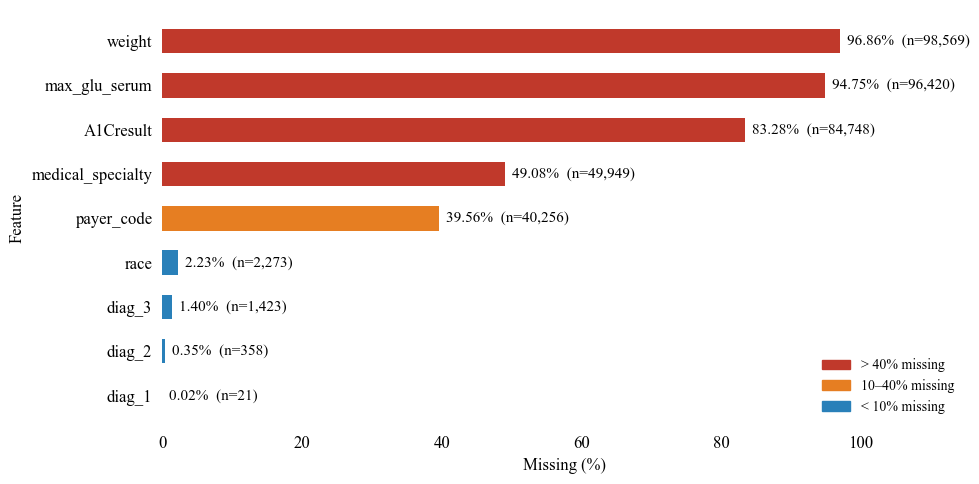

In [4]:
# Load the dataset and evaluate data missingness
full_dataset = pd.read_csv('Input/diabetic_data.csv')

# Compute missing values
missing_data = {}
for col in full_dataset.columns:
    missing_count = full_dataset.loc[
        (full_dataset[col] == '?') | (full_dataset[col].isnull())
    ].shape[0]
    if missing_count > 0:
        missing_data[col] = missing_count

total = len(full_dataset)
missing_pct = {col: round((cnt / total) * 100, 2) for col, cnt in missing_data.items()}

# Sort ascending by percentage
sorted_data = sorted(zip(missing_pct.values(), missing_data.values(), missing_pct.keys()))
pct_sorted, counts_sorted, cols_sorted = zip(*sorted_data)

def get_color(p):
    if p >= 40:
        return '#C0392B'
    elif p >= 10:
        return '#E67E22'
    else:
        return '#2980B9'

# Plotting 
colors = [get_color(p) for p in pct_sorted]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(cols_sorted, pct_sorted, color=colors, edgecolor='none', height=0.55)

for bar, pct, cnt in zip(bars, pct_sorted, counts_sorted):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{pct:.2f}%  (n={cnt:,})', va='center', ha='left', fontsize=11)

ax.set_xlim(0, 115)
ax.set_xlabel('Missing (%)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
ax.grid(False)

legend_patches = [
    mpatches.Patch(color='#C0392B', label='> 40% missing'),
    mpatches.Patch(color='#E67E22', label='10–40% missing'),
    mpatches.Patch(color='#2980B9', label='< 10% missing'),
]
ax.legend(handles=legend_patches, loc='lower right', frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig('Output/missing_values.png', dpi=300, bbox_inches='tight')
plt.show()


Dataset shape after preprocessing: (99474, 48)

--- Readmitted Column Inspection ---
Unique values: ['NO' '>30' '<30']

Value counts:
readmitted
NO     53306
>30    35004
<30    11164
Name: count, dtype: int64

Value counts (%):
readmitted
NO     53.59
>30    35.19
<30    11.22
Name: proportion, dtype: float64

--- Readmitted Column After Binarization ---
readmitted
0    88310
1    11164
Name: count, dtype: int64
readmitted
0    88.78
1    11.22
Name: proportion, dtype: float64


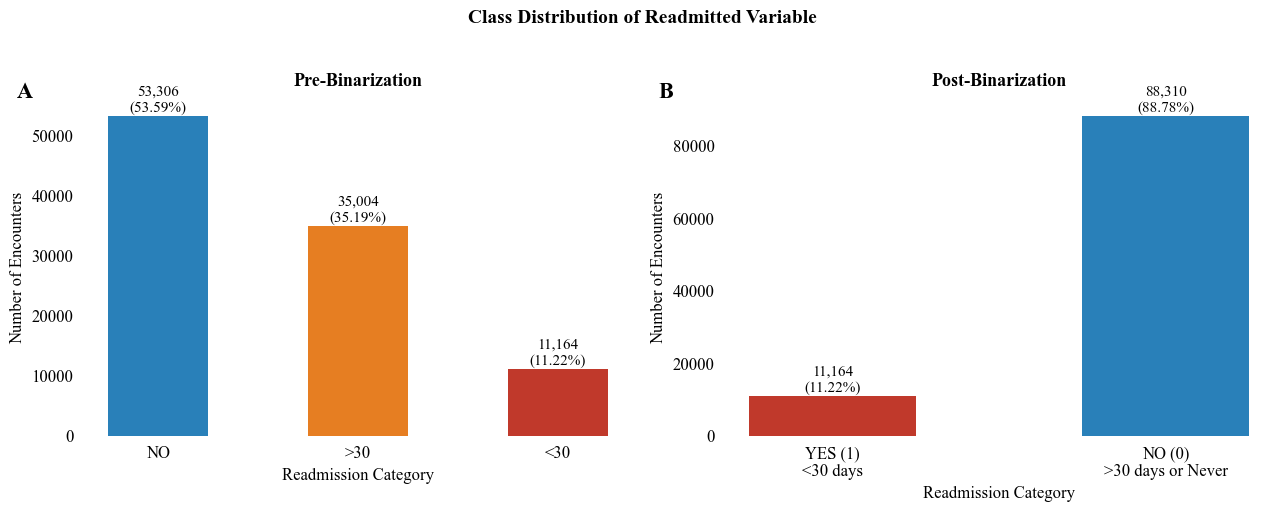

In [5]:
# missing value handling; replace ? with NA, dropping some columns, and filling others as described in report

full_dataset.replace('?', pd.NA, inplace=True)
full_dataset.drop(columns=['weight', 'payer_code'], inplace=True)
full_dataset.dropna(subset=['race', 'diag_1'], inplace=True)
full_dataset['diag_2'].fillna('None', inplace=True)
full_dataset['diag_3'].fillna('None', inplace=True)
full_dataset['A1Cresult'].fillna('Not_Tested', inplace=True)
full_dataset['medical_specialty'].fillna('Unknown', inplace=True)

print(f"Dataset shape after preprocessing: {full_dataset.shape}")

# Readmission columns, inspection and binarization

print("\n--- Readmitted Column Inspection ---")
print(f"Unique values: {full_dataset['readmitted'].unique()}")
print(f"\nValue counts:")
print(full_dataset['readmitted'].value_counts())
print(f"\nValue counts (%):")
print(round(full_dataset['readmitted'].value_counts(normalize=True) * 100, 2))

raw_counts = full_dataset['readmitted'].value_counts()

full_dataset['readmitted'] = full_dataset['readmitted'].apply(
    lambda x: 1 if x == '<30' else 0
)

print("\n--- Readmitted Column After Binarization ---")
print(full_dataset['readmitted'].value_counts())
print(round(full_dataset['readmitted'].value_counts(normalize=True) * 100, 2))

# Class distribution plot; before and after binarization

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.subplots_adjust(wspace=0.35)

# ── Panel A: Pre-binarization ──
raw_labels = raw_counts.index.tolist()
raw_vals   = raw_counts.values.tolist()
raw_colors = ['#2980B9', '#E67E22', '#C0392B']

bars1 = ax1.bar(raw_labels, raw_vals, color=raw_colors[:len(raw_labels)],
                edgecolor='none', width=0.5)
for bar, val in zip(bars1, raw_vals):
    pct = round(val / sum(raw_vals) * 100, 2)
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
             f'{val:,}\n({pct}%)', ha='center', va='bottom', fontsize=11)

ax1.set_xlabel('Readmission Category', fontsize=12)
ax1.set_ylabel('Number of Encounters', fontsize=12)
ax1.set_title('Pre-Binarization', fontsize=13, fontweight='bold', pad=10)
ax1.text(-0.12, 1.05, 'A', transform=ax1.transAxes,
         fontsize=16, fontweight='bold', va='top')

for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.yaxis.set_ticks_position('none')
ax1.xaxis.set_ticks_position('none')
ax1.grid(False)

# ── Panel B: Post-binarization ──
bin_counts = full_dataset['readmitted'].value_counts().sort_index(ascending=False)
bin_labels = ['YES (1)\n<30 days', 'NO (0)\n>30 days or Never']
bin_vals   = bin_counts.values.tolist()
bin_colors = ['#C0392B', '#2980B9']

bars2 = ax2.bar(bin_labels, bin_vals, color=bin_colors,
                edgecolor='none', width=0.5)
for bar, val in zip(bars2, bin_vals):
    pct = round(val / sum(bin_vals) * 100, 2)
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
             f'{val:,}\n({pct}%)', ha='center', va='bottom', fontsize=11)

ax2.set_xlabel('Readmission Category', fontsize=12)
ax2.set_ylabel('Number of Encounters', fontsize=12)
ax2.set_title('Post-Binarization', fontsize=13, fontweight='bold', pad=10)
ax2.text(-0.12, 1.05, 'B', transform=ax2.transAxes,
         fontsize=16, fontweight='bold', va='top')

for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.yaxis.set_ticks_position('none')
ax2.xaxis.set_ticks_position('none')
ax2.grid(False)

plt.suptitle('Class Distribution of Readmitted Variable',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('Output/class_dist_combined.png', dpi=300, bbox_inches='tight')
plt.show()


Medication columns after preprocessing:
['metformin', 'insulin', 'meds_active', 'meds_increased', 'meds_decreased']

Dataset shape: (99474, 30)


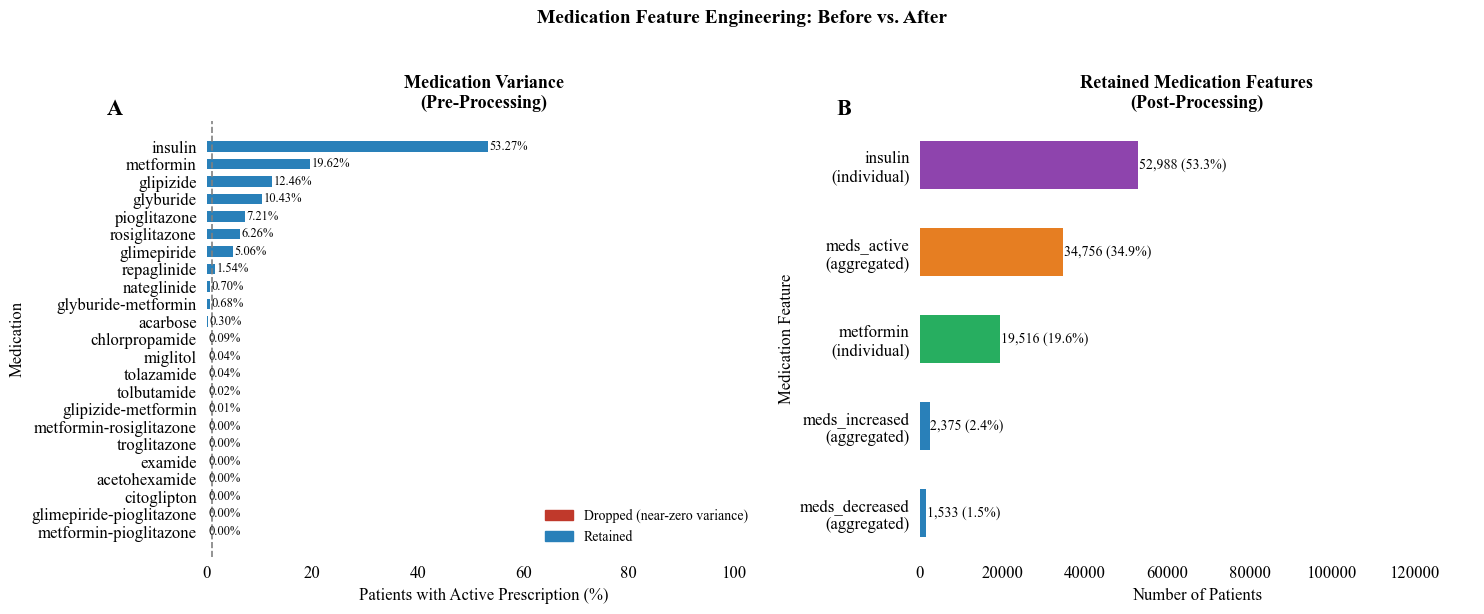

In [6]:
# Cleaning up medications column; alot of near-zero variance values

# All medication columns in the dataset
med_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

# Near-zero variance columns to drop - determined upon visualization of data
drop_meds = [
    'examide', 'citoglipton', 'acetohexamide', 'troglitazone',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]

# Medications to retain individually
keep_individual = ['insulin', 'metformin']

# Compute the variance within each group

variance_data = {}
for col in med_cols:
    active_pct = round((full_dataset[col] != 'No').sum() / len(full_dataset) * 100, 2)
    variance_data[col] = active_pct

var_df = pd.DataFrame.from_dict(variance_data, orient='index', columns=['active_pct'])
var_df = var_df.sort_values('active_pct', ascending=True)

# Drop all near variance columns
full_dataset.drop(columns=drop_meds, inplace=True)

# Define Remaining meds to aggregate (exclude insulin and metformin)
agg_med_cols = [c for c in med_cols if c not in drop_meds and c not in keep_individual]

full_dataset['meds_active']    = (full_dataset[agg_med_cols] == 'Steady').sum(axis=1)
full_dataset['meds_increased'] = (full_dataset[agg_med_cols] == 'Up').sum(axis=1)
full_dataset['meds_decreased'] = (full_dataset[agg_med_cols] == 'Down').sum(axis=1)

# Drop original aggregated columns after combining
full_dataset.drop(columns=agg_med_cols, inplace=True)

print("Medication columns after preprocessing:")
print([c for c in full_dataset.columns if c in keep_individual + ['meds_active', 'meds_increased', 'meds_decreased']])
print(f"\nDataset shape: {full_dataset.shape}")

# Plot medication features; before and after aggregation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.subplots_adjust(wspace=0.45)

# ── Panel A: Variance plot (before) ──
colors_var = ['#C0392B' if col in drop_meds else '#2980B9' for col in var_df.index]

ax1.barh(var_df.index, var_df['active_pct'], color=colors_var, edgecolor='none', height=0.6)
ax1.axvline(x=1, linestyle='--', color='gray', linewidth=1.2)  # near-zero variance threshold

for i, (val, col) in enumerate(zip(var_df['active_pct'], var_df.index)):
    ax1.text(val + 0.3, i, f'{val:.2f}%', va='center', fontsize=9)

ax1.set_xlabel('Patients with Active Prescription (%)', fontsize=12)
ax1.set_ylabel('Medication', fontsize=12)
ax1.set_title('Medication Variance\n(Pre-Processing)', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlim(0, 105)
ax1.text(-0.18, 1.05, 'A', transform=ax1.transAxes, fontsize=16, fontweight='bold', va='top')

# Legend
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color='#C0392B', label='Dropped (near-zero variance)'),
    mpatches.Patch(color='#2980B9', label='Retained'),
]
ax1.legend(handles=legend_patches, loc='lower right', frameon=False, fontsize=10)

for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.xaxis.set_ticks_position('none')
ax1.yaxis.set_ticks_position('none')
ax1.grid(False)

# ── Panel B: Summary of retained features (after) — horizontal ──
after_features = {
    'meds_decreased\n(aggregated)': (full_dataset['meds_decreased'] > 0).sum(),
    'meds_increased\n(aggregated)': (full_dataset['meds_increased'] > 0).sum(),
    'metformin\n(individual)':      (full_dataset['metformin'] != 'No').sum(),
    'meds_active\n(aggregated)':    (full_dataset['meds_active'] > 0).sum(),
    'insulin\n(individual)':        (full_dataset['insulin'] != 'No').sum(),    
}

after_colors = ['#2980B9', '#2980B9', '#27AE60', '#E67E22', '#8E44AD']
bars2 = ax2.barh(list(after_features.keys()), list(after_features.values()),
                 color=after_colors, edgecolor='none', height=0.55)

for bar, val in zip(bars2, after_features.values()):
    pct = round(val / len(full_dataset) * 100, 1)
    ax2.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
             f'{val:,} ({pct}%)', va='center', ha='left', fontsize=10)

ax2.set_xlabel('Number of Patients', fontsize=12)
ax2.set_ylabel('Medication Feature', fontsize=12)
ax2.set_xlim(0, len(full_dataset) * 1.35)
ax2.set_title('Retained Medication Features\n(Post-Processing)', fontsize=13, fontweight='bold', pad=10)
ax2.text(-0.15, 1.05, 'B', transform=ax2.transAxes, fontsize=16, fontweight='bold', va='top')

for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.xaxis.set_ticks_position('none')
ax2.yaxis.set_ticks_position('none')
ax2.grid(False)


plt.suptitle('Medication Feature Engineering: Before vs. After',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('Output/medication_preprocessing.png', dpi=300, bbox_inches='tight')
plt.show()


Total dataset:         n = 99,474
Train + Val set (80%): n = 79,337
Test set (20%):        n = 20,137

Unique patients in train: 55,641
Unique patients in test:  14,018
Patient overlap:          0

--- Class proportions per split ---

Full Dataset
(n=99,474)
readmitted
0    88.78
1    11.22

Train + Val
(n=79,337)
readmitted
0    88.84
1    11.16

Test Set
(n=20,137)
readmitted
0    88.52
1    11.48


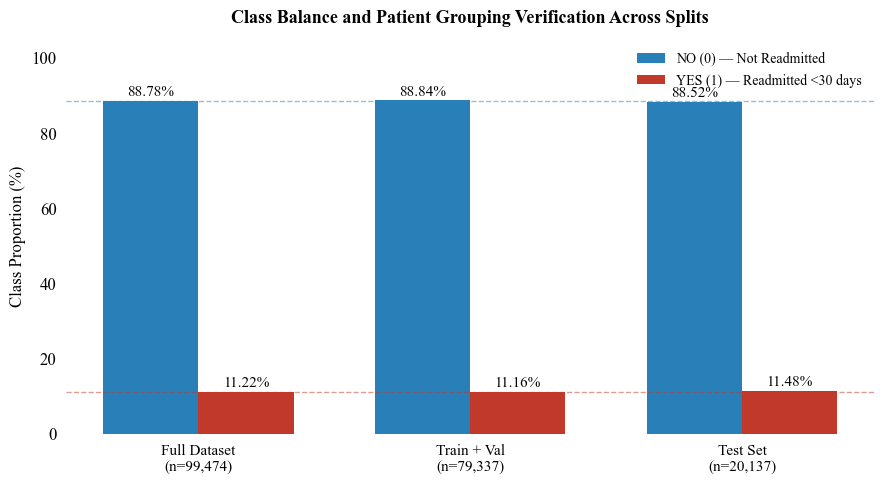


--- Descriptive Stats: Class counts per split ---
            Split  Total (n)  NO (0) — n  NO (0) — %  YES (1) — n  YES (1) — %
     Full Dataset      99474       88310       88.78        11164        11.22
Train + Val (80%)      79337       70485       88.84         8852        11.16
   Test Set (20%)      20137       17825       88.52         2312        11.48


In [7]:
# Dataset splitting for training 

X = full_dataset.drop(columns=['readmitted'])
y = full_dataset['readmitted']
groups = full_dataset['patient_nbr']  # group by patient to prevent leakage

# splits = 80/20, stratified by class, grouped by patient
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(X, y, groups=groups))

X_trainval = X.iloc[train_idx].reset_index(drop=True)
X_test     = X.iloc[test_idx].reset_index(drop=True)
y_trainval = y.iloc[train_idx].reset_index(drop=True)
y_test     = y.iloc[test_idx].reset_index(drop=True)

total      = len(full_dataset)
n_trainval = len(X_trainval)
n_test     = len(X_test)

print(f"Total dataset:         n = {total:,}")
print(f"Train + Val set (80%): n = {n_trainval:,}")
print(f"Test set (20%):        n = {n_test:,}")

# Verify no patient overlap between sets
train_patients = set(full_dataset.iloc[train_idx]['patient_nbr'])
test_patients  = set(full_dataset.iloc[test_idx]['patient_nbr'])
overlap        = train_patients & test_patients
print(f"\nUnique patients in train: {len(train_patients):,}")
print(f"Unique patients in test:  {len(test_patients):,}")
print(f"Patient overlap:          {len(overlap)}")


# ── Class distribution per split ──
splits = {
    f'Full Dataset\n(n={total:,})':        y,
    f'Train + Val\n(n={n_trainval:,})':    y_trainval,
    f'Test Set\n(n={n_test:,})':           y_test,
}

print("\n--- Class proportions per split ---")
for name, labels in splits.items():
    vc = labels.value_counts(normalize=True).round(4) * 100
    print(f"\n{name.strip()}")
    print(vc.to_string())

# Plot balance across splits

split_names  = list(splits.keys())
pct_negative = []
pct_positive = []

for labels in splits.values():
    vc = labels.value_counts(normalize=True) * 100
    pct_negative.append(round(vc.get(0, 0), 2))
    pct_positive.append(round(vc.get(1, 0), 2))

x     = np.arange(len(split_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2, pct_negative, width, label='NO (0) — Not Readmitted',
               color='#2980B9', edgecolor='none')
bars2 = ax.bar(x + width/2, pct_positive, width, label='YES (1) — Readmitted <30 days',
               color='#C0392B', edgecolor='none')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=11)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=11)

ax.axhline(y=pct_negative[0], linestyle='--', color='#2980B9', linewidth=1, alpha=0.5)
ax.axhline(y=pct_positive[0], linestyle='--', color='#C0392B', linewidth=1, alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(split_names, fontsize=11)
ax.set_ylabel('Class Proportion (%)', fontsize=12)
ax.set_ylim(0, 105)
ax.set_title('Class Balance and Patient Grouping Verification Across Splits',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='upper right', frameon=False, fontsize=10)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
ax.grid(False)

plt.tight_layout()
plt.savefig('Output/split_balance.png', dpi=300, bbox_inches='tight')
plt.show()

# Descriptive stats table
print("\n--- Descriptive Stats: Class counts per split ---")
summary = pd.DataFrame({
    'Split':       ['Full Dataset', 'Train + Val (80%)', 'Test Set (20%)'],
    'Total (n)':   [total, n_trainval, n_test],
    'NO (0) — n':  [int((y == 0).sum()),        int((y_trainval == 0).sum()),  int((y_test == 0).sum())],
    'NO (0) — %':  [round((y == 0).mean()*100, 2), round((y_trainval == 0).mean()*100, 2), round((y_test == 0).mean()*100, 2)],
    'YES (1) — n': [int((y == 1).sum()),        int((y_trainval == 1).sum()),  int((y_test == 1).sum())],
    'YES (1) — %': [round((y == 1).mean()*100, 2), round((y_trainval == 1).mean()*100, 2), round((y_test == 1).mean()*100, 2)],
})
print(summary.to_string(index=False))




In [8]:
#Summary file
full_dataset['diabetesMed'].describe()

count     99474
unique        2
top         Yes
freq      76477
Name: diabetesMed, dtype: object

Numerical features:   16 → ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'meds_active', 'meds_increased', 'meds_decreased']
Categorical features: 13 → ['race', 'gender', 'age', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'insulin', 'change', 'diabetesMed']


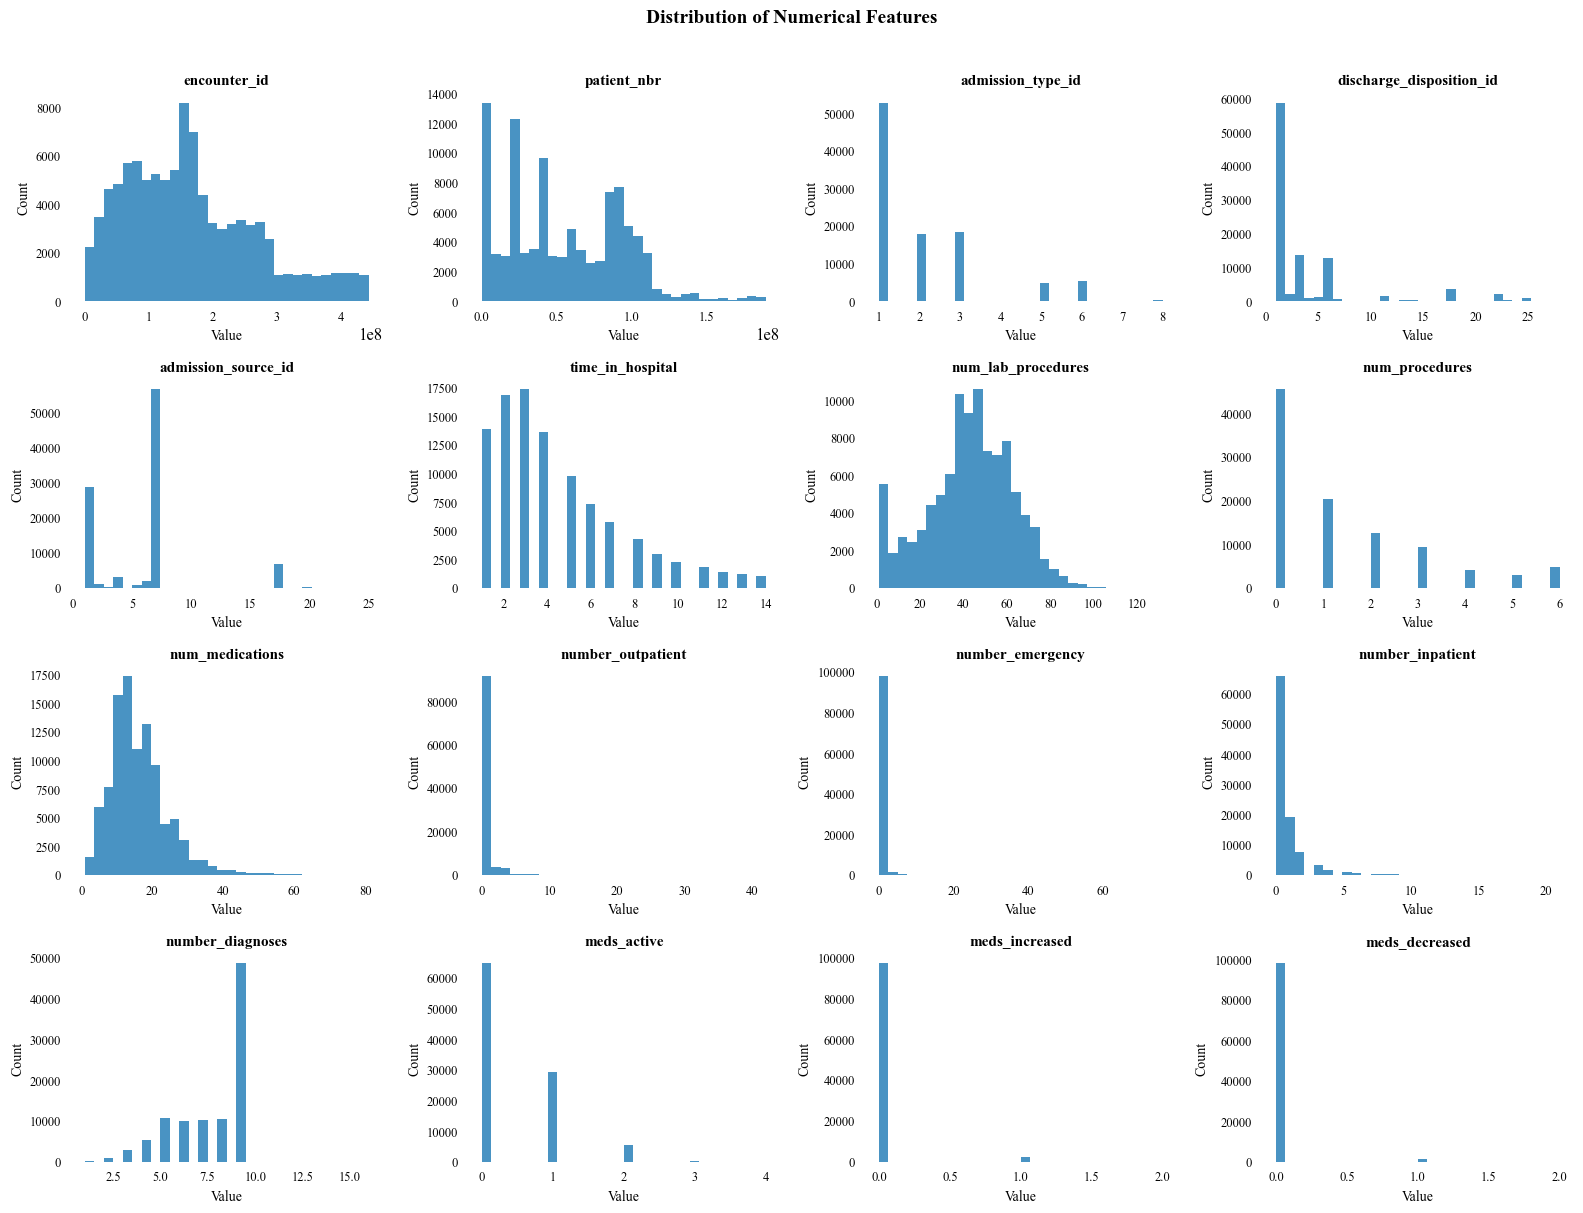

Saved: dist_numerical.png


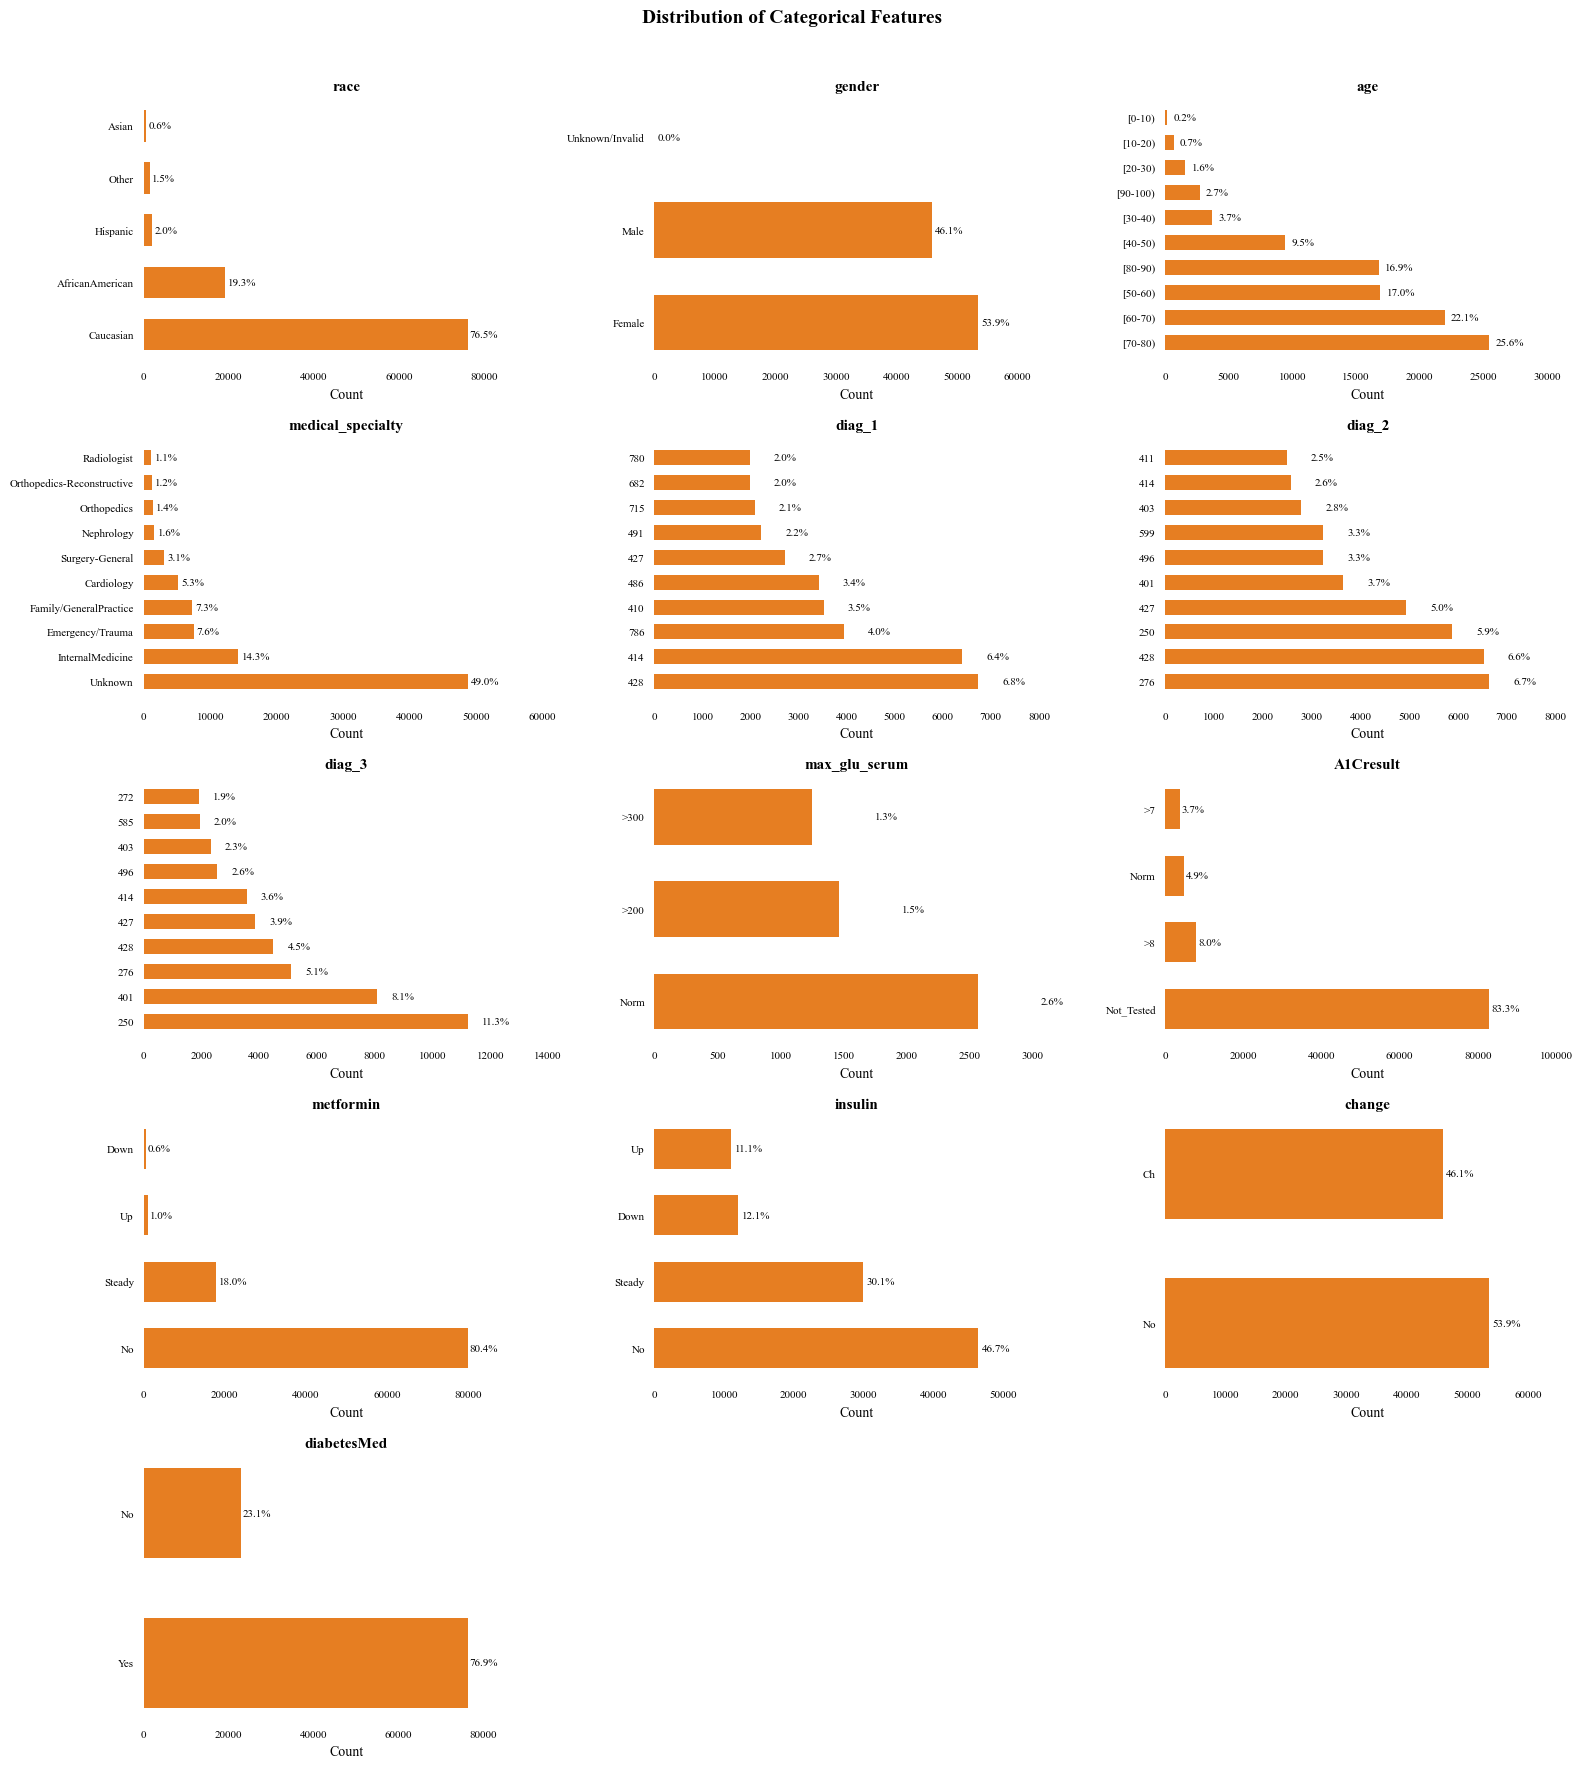

Saved: dist_categorical.png


In [9]:
# Summary plots - categorical and numerical

# Separate numerical and categorical columns
exclude_cols = ['readmitted']

num_cols = [c for c in X.select_dtypes(include=['int64', 'float64']).columns if c not in exclude_cols]
cat_cols = [c for c in X.select_dtypes(include=['object', 'category']).columns if c not in exclude_cols]

print(f"Numerical features:   {len(num_cols)} → {num_cols}")
print(f"Categorical features: {len(cat_cols)} → {cat_cols}")

# Histograms of numerical distributions

ncols = 4
nrows = math.ceil(len(num_cols) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = X[col].dropna()
    ax.hist(data, bins=30, color='#2980B9', edgecolor='none', alpha=0.85)
    ax.set_title(col, fontsize=11, fontweight='bold', pad=6)
    ax.set_xlabel('Value', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.tick_params(labelsize=9)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.grid(False)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('Output/dist_numerical.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: dist_numerical.png")

# bar plots of categorical distribution

ncols = 3
nrows = math.ceil(len(cat_cols) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    vc = X[col].value_counts().head(10)  # cap at top 10 for readability

    bars = ax.barh(vc.index.astype(str), vc.values,
                   color='#E67E22', edgecolor='none', height=0.6)

    for bar, val in zip(bars, vc.values):
        pct = round(val / len(X) * 100, 1)
        ax.text(bar.get_width() + len(X) * 0.005,
                bar.get_y() + bar.get_height() / 2,
                f'{pct}%', va='center', fontsize=8)

    ax.set_title(col, fontsize=11, fontweight='bold', pad=6)
    ax.set_xlabel('Count', fontsize=10)
    ax.set_xlim(0, vc.values.max() * 1.25)
    ax.tick_params(labelsize=8)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.grid(False)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution of Categorical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('Output/dist_categorical.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: dist_categorical.png")



        ASSUMPTION TESTING REPORT

[ALL MODELS] Class Imbalance Check
----------------------------------------
readmitted
0    70485
1     8852
Imbalance ratio (majority:minority): 7.96:1
Violation

[ALL MODELS] Sample Size Adequacy
----------------------------------------
Training set size:          n = 79,337
Number of features:         p = 29
Minority class size:        n = 8,852
Events per predictor (EPP):     305.24
Pass

[ALL MODELS] Independence of Observations
 Multiple encounters per patient exist.
 StratifiedGroupKFold applied — no patient in both sets.
 Residual within-patient correlation flagged as limitation.

[LOGISTIC REGRESSION] Multicollinearity — VIF
----------------------------------------
                 Feature      VIF      Status
         num_medications 1.706750  Acceptable
                  change 1.635914  Acceptable
            encounter_id 1.569058  Acceptable
             diabetesMed 1.552238  Acceptable
           max_glu_serum 1.471732  Acceptable
      

/opt/homebrew/Caskroom/miniforge/base/envs/tf_m1/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                 Feature  p-value     Result
            encounter_id   0.0596         OK
             patient_nbr   0.0001  Violation
       admission_type_id   0.0495  Violation
discharge_disposition_id   0.0000  Violation
     admission_source_id   0.0002  Violation
        time_in_hospital   0.0000  Violation
      num_lab_procedures   0.1064         OK
          num_procedures   0.0000  Violation
         num_medications   0.0000  Violation
       number_outpatient   0.0000  Violation
        number_emergency   0.0000  Violation
        number_inpatient   0.0000  Violation
        number_diagnoses   0.1161         OK
             meds_active   0.8054         OK
          meds_increased   0.5501         OK
          meds_decreased      NaN         OK

Note: p < 0.05 = non-linear 

[LOGISTIC REGRESSION + NEURAL NETWORK] Outlier Check (IQR)
----------------------------------------
                 Feature  N outliers  % outliers Status
       number_outpatient       13181       16.61

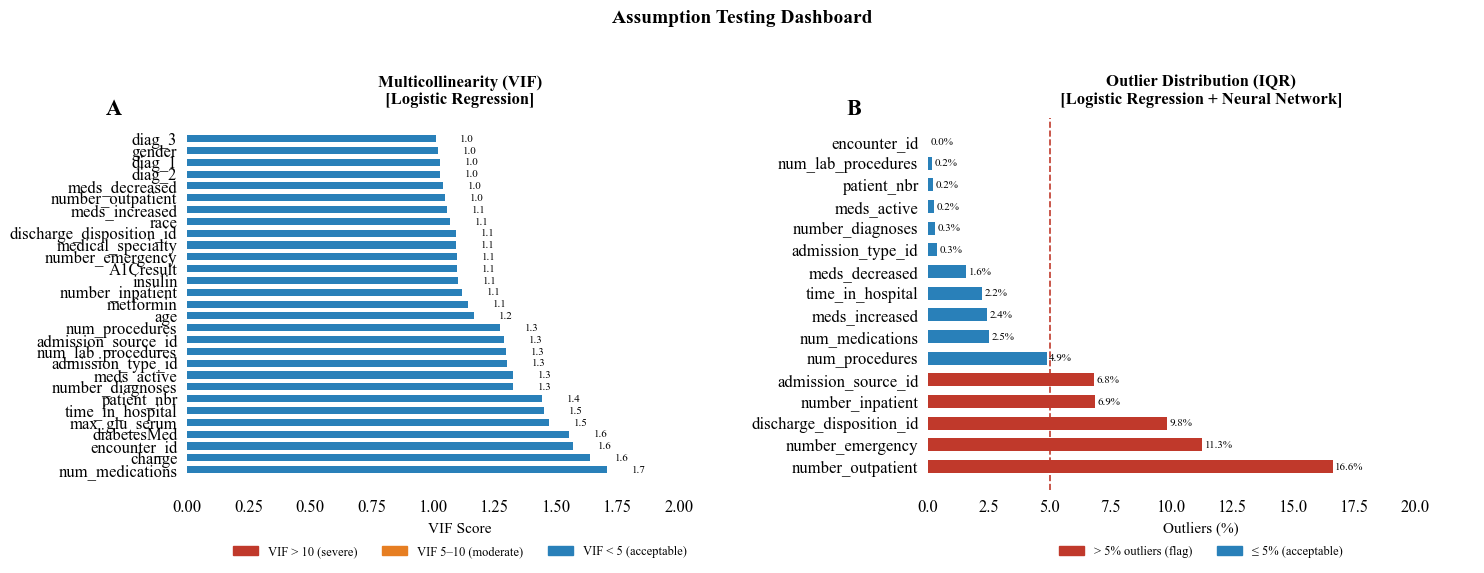

✓ Saved: assumption_testing.png


In [10]:
# Assumption testing for all model - utilized claude ai for generating and streamlining this section

from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from docx import Document
from docx.shared import Pt, RGBColor, Inches
from docx.enum.table import WD_TABLE_ALIGNMENT

# Encode X for numeric testing
X_encoded = X_trainval.copy()
for col in X_encoded.select_dtypes(include='object').columns:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col].astype(str))
X_encoded = X_encoded.fillna(0)

# Start Word document
doc = Document()
doc.add_heading('Assumption Testing Report', 0)

def add_table_to_doc(doc, title, headers, rows, pass_col_idx=None):
    """Helper: adds a titled table to the Word doc with optional green/red status colouring."""
    doc.add_heading(title, level=2)
    table = doc.add_table(rows=1, cols=len(headers))
    table.style = 'Light Grid Accent 1'
    table.alignment = WD_TABLE_ALIGNMENT.CENTER
    hdr_cells = table.rows[0].cells
    for i, h in enumerate(headers):
        hdr_cells[i].text = h
        for run in hdr_cells[i].paragraphs[0].runs:
            run.bold = True
    for row_data in rows:
        row_cells = table.add_row().cells
        for i, val in enumerate(row_data):
            row_cells[i].text = str(val)
            if pass_col_idx is not None and i == pass_col_idx:
                color = RGBColor(0x27, 0xAE, 0x60) if '✓' in str(val) else RGBColor(0xC0, 0x39, 0x2B)
                for para in row_cells[i].paragraphs:
                    for run in para.runs:
                        run.font.color.rgb = color
                        run.bold = True
    doc.add_paragraph()

print("        ASSUMPTION TESTING REPORT")

#Class imbalance test

print("\n[ALL MODELS] Class Imbalance Check")
print("-" * 40)
class_counts = y_trainval.value_counts()
ratio        = class_counts[0] / class_counts[1]
status_imb   = "Violation" if ratio > 3 else "Pass"
print(class_counts.to_string())
print(f"Imbalance ratio (majority:minority): {ratio:.2f}:1")
print(status_imb)

add_table_to_doc(doc, "1. Class Imbalance (All Models)",
    headers=["Class", "Count", "Proportion (%)", "Ratio", "Status"],
    rows=[
        ["NO (0)", f"{class_counts[0]:,}", f"{round(class_counts[0]/len(y_trainval)*100,2)}%",
         f"{ratio:.2f}:1", status_imb],
        ["YES (1)", f"{class_counts[1]:,}", f"{round(class_counts[1]/len(y_trainval)*100,2)}%", "—", "—"],
    ], pass_col_idx=4)

# Sample size

print("\n[ALL MODELS] Sample Size Adequacy")
print("-" * 40)
n_total    = len(X_trainval)
n_features = X_encoded.shape[1]
n_minority = class_counts.min()
epp        = round(n_minority / n_features, 2)
status_epp = "Pass" if epp >= 10 else "Violation"
print(f"Training set size:          n = {n_total:,}")
print(f"Number of features:         p = {n_features}")
print(f"Minority class size:        n = {n_minority:,}")
print(f"Events per predictor (EPP):     {epp}")
print(status_epp)

add_table_to_doc(doc, "2. Sample Size Adequacy (All Models)",
    headers=["Metric", "Value", "Threshold", "Status"],
    rows=[
        ["Training set size (n)", f"{n_total:,}", "—", "—"],
        ["Number of features (p)", str(n_features), "—", "—"],
        ["Minority class size", f"{n_minority:,}", "—", "—"],
        ["Events per predictor (EPP)", str(epp), "≥ 10", status_epp],
    ], pass_col_idx=3)

#Independence

print("\n[ALL MODELS] Independence of Observations")
print(" Multiple encounters per patient exist.")
print(" StratifiedGroupKFold applied — no patient in both sets.")
print(" Residual within-patient correlation flagged as limitation.")

add_table_to_doc(doc, "3. Independence of Observations (All Models)",
    headers=["Check", "Approach", "Status"],
    rows=[
        ["Multiple encounters per patient", "StratifiedGroupKFold by patient_nbr", " Addressed"],
        ["Residual within-patient correlation", "Flagged as study limitation", " Limitation"],
    ], pass_col_idx=2)

# Logistic regression - VIF testing 

print("\n[LOGISTIC REGRESSION] Multicollinearity — VIF")
print("-" * 40)

X_vif    = sm.add_constant(X_encoded)
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF']     = [variance_inflation_factor(X_vif.values, i)
                        for i in range(X_vif.shape[1])]
vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values('VIF', ascending=False)
vif_data['Status'] = vif_data['VIF'].apply(
    lambda v: ' Severe' if v > 10 else (' Moderate' if v > 5 else ' Acceptable'))

print(vif_data.to_string(index=False))
high_vif = vif_data[vif_data['VIF'] > 10]
print(f"\n{'caution' if len(high_vif) > 0 else 'ok'} {len(high_vif)} feature(s) with VIF > 10")

add_table_to_doc(doc, "4. Multicollinearity — VIF (Logistic Regression)",
    headers=["Feature", "VIF", "Status"],
    rows=[[row['Feature'], f"{row['VIF']:.2f}", row['Status']]
          for _, row in vif_data.iterrows()],
    pass_col_idx=2)

# Logistic regression - box tidwell

print("\n[LOGISTIC REGRESSION] Linearity of Log-Odds — Box-Tidwell")
print("-" * 40)

num_features = [
    col for col in X_trainval.select_dtypes(include=['int64', 'float64']).columns
    if X_trainval[col].nunique() > 2
]

X_bt = X_encoded[num_features].copy()
for col in X_bt.columns:
    min_val = X_bt[col].min()
    if min_val <= 0:
        X_bt[col] = X_bt[col] + abs(min_val) + 1

bt_results = []
for col in X_bt.columns:
    try:
        interaction = X_bt[col] * np.log(X_bt[col])
        df_bt       = pd.DataFrame({col: X_bt[col], f'{col}_log': interaction})
        df_bt       = sm.add_constant(df_bt)
        model       = sm.Logit(y_trainval.values, df_bt).fit(disp=0)
        p_val       = model.pvalues[f'{col}_log']
        flag        = ' Violation' if p_val < 0.05 else 'OK'
        bt_results.append({'Feature': col, 'p-value': round(p_val, 4), 'Result': flag})
    except Exception as e:
        bt_results.append({'Feature': col, 'p-value': 'Error', 'Result': str(e)})

bt_df = pd.DataFrame(bt_results)
print(bt_df.to_string(index=False))
print("\nNote: p < 0.05 = non-linear ")

add_table_to_doc(doc, "5. Linearity of Log-Odds — Box-Tidwell (Logistic Regression)",
    headers=["Feature", "p-value (interaction)", "Result"],
    rows=[[r['Feature'], str(r['p-value']), r['Result']] for r in bt_results],
    pass_col_idx=2)

# Outlier Check

print("\n[LOGISTIC REGRESSION + NEURAL NETWORK] Outlier Check (IQR)")
print("-" * 40)

outlier_summary = []
for col in num_features:
    Q1    = X_trainval[col].quantile(0.25)
    Q3    = X_trainval[col].quantile(0.75)
    IQR   = Q3 - Q1
    n_out = ((X_trainval[col] < Q1 - 1.5 * IQR) |
             (X_trainval[col] > Q3 + 1.5 * IQR)).sum()
    pct   = round(n_out / len(X_trainval) * 100, 2)
    flag  = 'Flag' if pct > 5 else 'OK'
    outlier_summary.append({'Feature': col, 'N outliers': n_out, '% outliers': pct, 'Status': flag})

out_df  = pd.DataFrame(outlier_summary).sort_values('% outliers', ascending=False)
print(out_df.to_string(index=False))
flagged = out_df[out_df['% outliers'] > 5]
print(f"\n{'caution' if len(flagged) > 0 else 'ok'} {len(flagged)} feature(s) with >5% outliers")

add_table_to_doc(doc, "6. Outlier Distribution — IQR (Logistic Regression + Neural Network)",
    headers=["Feature", "N Outliers", "% Outliers", "Status"],
    rows=[[r['Feature'], f"{r['N outliers']:,}", f"{r['% outliers']}%", r['Status']]
          for _, r in out_df.iterrows()],
    pass_col_idx=3)

# Feature Scale Check

print("\n[NEURAL NETWORK] Feature Scale Check")
print("-" * 40)
scale_summary = []
for col in num_features:
    col_range = X_trainval[col].max() - X_trainval[col].min()
    col_std   = X_trainval[col].std()
    scale_summary.append({'Feature': col, 'Range': round(col_range, 2), 'Std Dev': round(col_std, 2)})

scale_df = pd.DataFrame(scale_summary).sort_values('Range', ascending=False)
print(scale_df.to_string(index=False))
print("\n⚠ Apply StandardScaler AFTER splitting — transform test set only, never fit!")

add_table_to_doc(doc, "7. Feature Scale Check (Neural Network)",
    headers=["Feature", "Range", "Std Dev", "Action Required"],
    rows=[[r['Feature'], str(r['Range']), str(r['Std Dev']), '⚠ Scale (StandardScaler)']
          for _, r in scale_df.iterrows()])

# Formal Assumption Check
print("\n[RANDOM FOREST + XGBOOST] Formal Assumption Check")
print("-" * 40)
print("No linearity, normality, or multicollinearity assumptions")
print("Robust to outliers — feature scaling not required")
print("Use class_weight='balanced' (RF) / scale_pos_weight (XGBoost)")

add_table_to_doc(doc, "8. Assumptions (Random Forest + XGBoost)",
    headers=["Assumption", "Required?", "Status", "Action"],
    rows=[
        ["Linearity",          "No",  "✓ N/A", "None"],
        ["Normality",          "No",  "✓ N/A", "None"],
        ["Multicollinearity",  "No",  "✓ N/A", "None"],
        ["Feature Scaling",    "No",  "✓ N/A", "None"],
        ["Class Imbalance",    "Yes", "⚠ Address", "class_weight='balanced' / scale_pos_weight"],
        ["Independence",       "No",  "✓ N/A", "StratifiedGroupKFold applied"],
    ], pass_col_idx=2)

# Save word doc
doc.save('Output/assumption_testing_report.docx')
print("\n✓ Saved: assumption_testing_report.docx")

# Summary plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Panel A: VIF ──
ax1        = axes[0]
colors_vif = ['#C0392B' if v > 10 else '#E67E22' if v > 5 else '#2980B9'
               for v in vif_data['VIF']]

ax1.barh(vif_data['Feature'], vif_data['VIF'], color=colors_vif, edgecolor='none', height=0.6)
ax1.axvline(x=10, linestyle='--', color='#C0392B', linewidth=1.2)
ax1.axvline(x=5,  linestyle='--', color='#E67E22', linewidth=1.2)
for i, val in enumerate(vif_data['VIF']):
    ax1.text(val + 0.1, i, f'{val:.1f}', va='center', fontsize=8)

ax1.set_xlabel('VIF Score', fontsize=11)
ax1.set_title('Multicollinearity (VIF)\n[Logistic Regression]',
              fontsize=12, fontweight='bold', pad=10)
ax1.set_xlim(0, vif_data['VIF'].max() * 1.3)
ax1.text(-0.15, 1.05, 'A', transform=ax1.transAxes,
         fontsize=16, fontweight='bold', va='top')

legend_vif = [
    mpatches.Patch(color='#C0392B', label='VIF > 10 (severe)'),
    mpatches.Patch(color='#E67E22', label='VIF 5–10 (moderate)'),
    mpatches.Patch(color='#2980B9', label='VIF < 5 (acceptable)'),
]
ax1.legend(handles=legend_vif, frameon=False, fontsize=9,
           loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)
for spine in ax1.spines.values(): spine.set_visible(False)
ax1.grid(False)
ax1.xaxis.set_ticks_position('none')
ax1.yaxis.set_ticks_position('none')

# ── Panel B: Outliers ──
ax2        = axes[1]
colors_out = ['#C0392B' if p > 5 else '#2980B9' for p in out_df['% outliers']]

ax2.barh(out_df['Feature'], out_df['% outliers'], color=colors_out, edgecolor='none', height=0.6)
ax2.axvline(x=5, linestyle='--', color='#C0392B', linewidth=1.2)
for i, val in enumerate(out_df['% outliers']):
    ax2.text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=8)

ax2.set_xlabel('Outliers (%)', fontsize=11)
ax2.set_title('Outlier Distribution (IQR)\n[Logistic Regression + Neural Network]',
              fontsize=12, fontweight='bold', pad=10)
ax2.set_xlim(0, out_df['% outliers'].max() * 1.35)
ax2.text(-0.15, 1.05, 'B', transform=ax2.transAxes,
         fontsize=16, fontweight='bold', va='top')

legend_out = [
    mpatches.Patch(color='#C0392B', label='> 5% outliers (flag)'),
    mpatches.Patch(color='#2980B9', label='≤ 5% (acceptable)'),
]
ax2.legend(handles=legend_out, frameon=False, fontsize=9,
           loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)
for spine in ax2.spines.values(): spine.set_visible(False)
ax2.grid(False)
ax2.xaxis.set_ticks_position('none')
ax2.yaxis.set_ticks_position('none')

plt.suptitle('Assumption Testing Dashboard', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('Output/assumption_testing.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: assumption_testing.png")


Mapping ICD-9 codes to disease categories...
ICD-9 mapping complete
diag_1
Circulatory            29654
Endocrine_Metabolic    11179
Respiratory            10171
Digestive               9036
Symptoms_Signs          7495
Injury                  6815
Genitourinary           4989
Musculoskeletal         4826
Neoplasms               3353
Infectious              2699
Name: count, dtype: int64

 Final feature matrix: 99,474 rows  180 features
Train+Val: 79,337 | Test: 20,137
Class balance — Train: 11.16% | Test: 11.48%

 LR Restricted features:  172
 LR Adjusted features:    192
 RF/XGBoost/NN features:  180

───────────────────────────────────────────────────────
LOGISTIC REGRESSION — LR_RESTRICTED | BALANCED
───────────────────────────────────────────────────────

Running 5-fold CV...
  CV roc_auc: [0.5937 0.5861 0.5662 0.5874 0.5828] | Mean: 0.5832 ± 0.0092


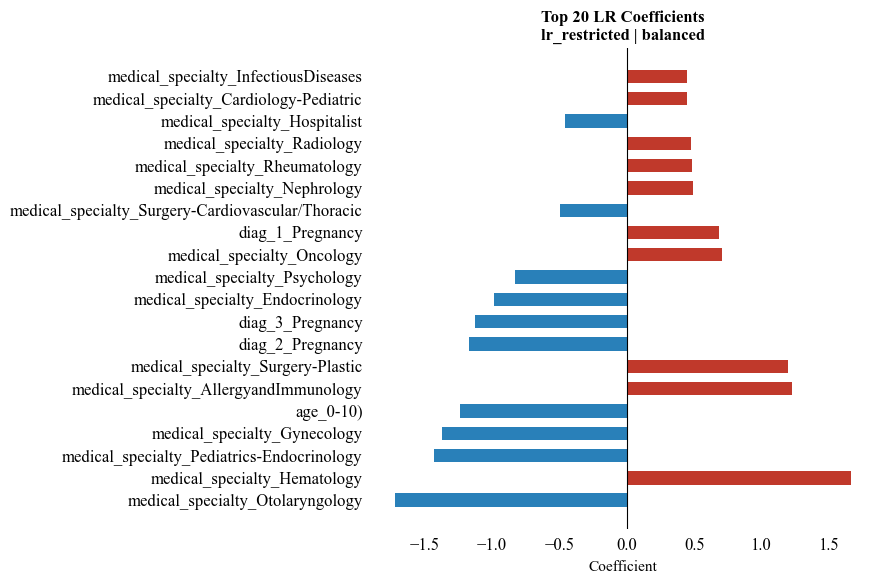


  EVALUATING: Lr Restricted (balanced)
AUROC:     0.5866
F1:        0.2290
Precision: 0.1424
Recall:    0.5843
AUC-PR:    0.1450

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.91      0.54      0.68     17825
    Readmitted       0.14      0.58      0.23      2312

      accuracy                           0.55     20137
     macro avg       0.53      0.56      0.45     20137
  weighted avg       0.82      0.55      0.63     20137



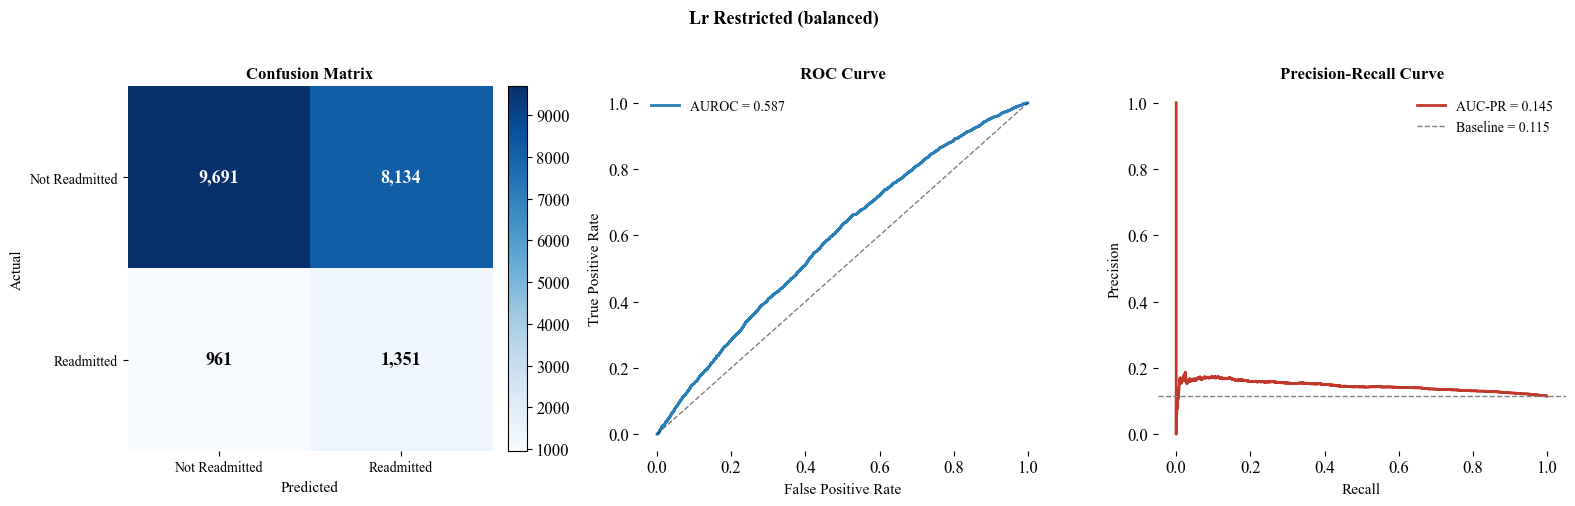

✓ Saved: eval_Lr_Restricted_balanced.png

───────────────────────────────────────────────────────
LOGISTIC REGRESSION — LR_ADJUSTED | BALANCED
───────────────────────────────────────────────────────

Running 5-fold CV...
  CV roc_auc: [0.6345 0.6439 0.6272 0.6371 0.636 ] | Mean: 0.6357 ± 0.0054


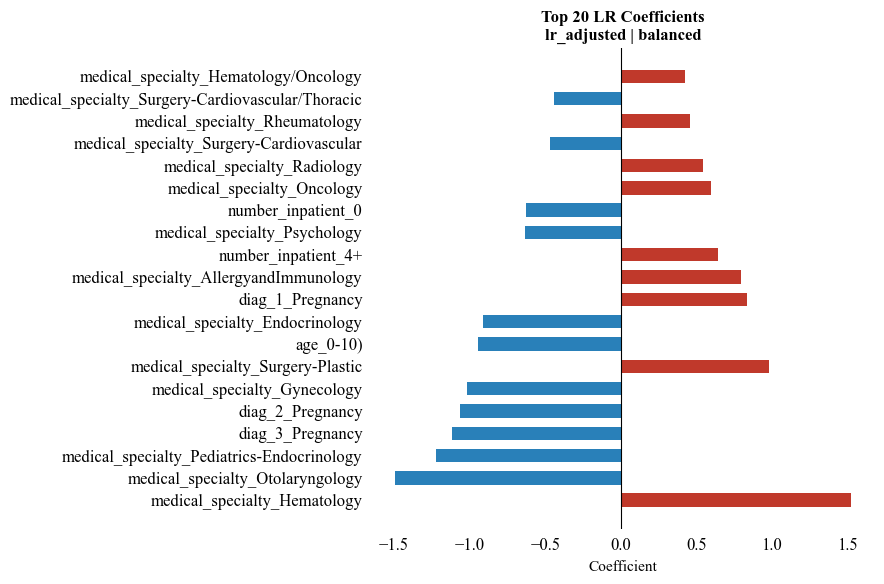


  EVALUATING: Lr Adjusted (balanced)
AUROC:     0.6390
F1:        0.2559
Precision: 0.1692
Recall:    0.5247
AUC-PR:    0.1905

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.92      0.67      0.77     17825
    Readmitted       0.17      0.52      0.26      2312

      accuracy                           0.65     20137
     macro avg       0.54      0.60      0.51     20137
  weighted avg       0.83      0.65      0.71     20137



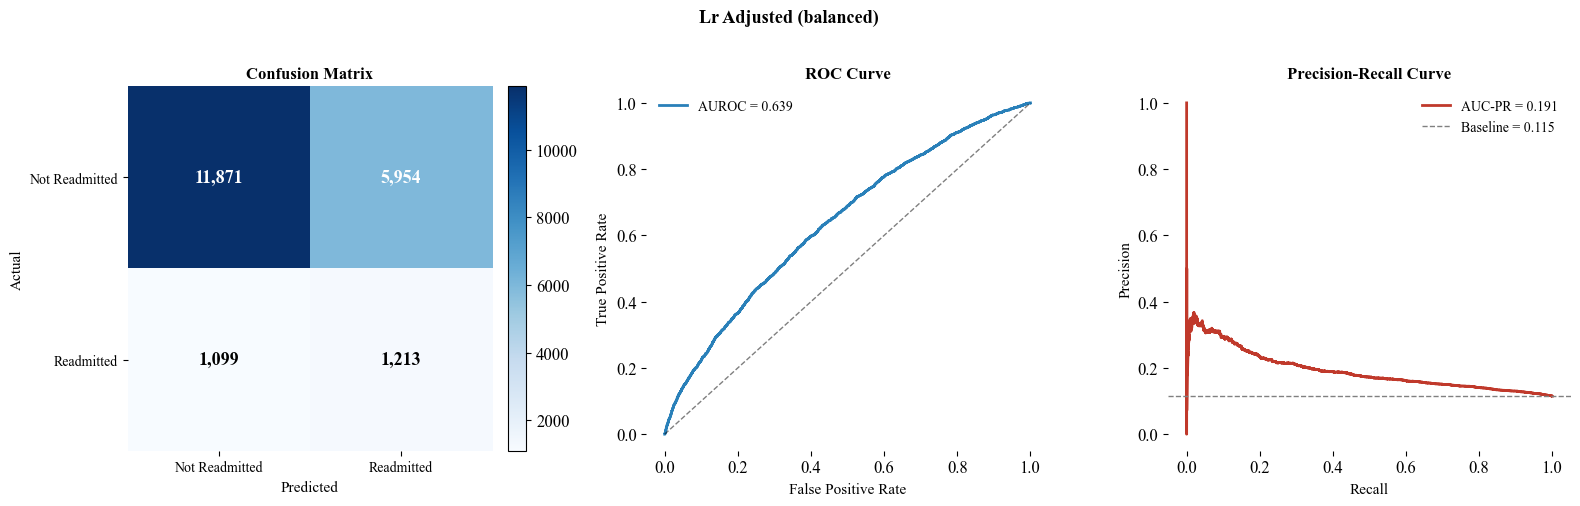

✓ Saved: eval_Lr_Adjusted_balanced.png

───────────────────────────────────────────────────────
LOGISTIC REGRESSION — LR_RESTRICTED | SMOTE
───────────────────────────────────────────────────────

Running 5-fold CV...
  CV roc_auc: [0.9445 0.9411 0.9434 0.9441 0.9453] | Mean: 0.9437 ± 0.0014


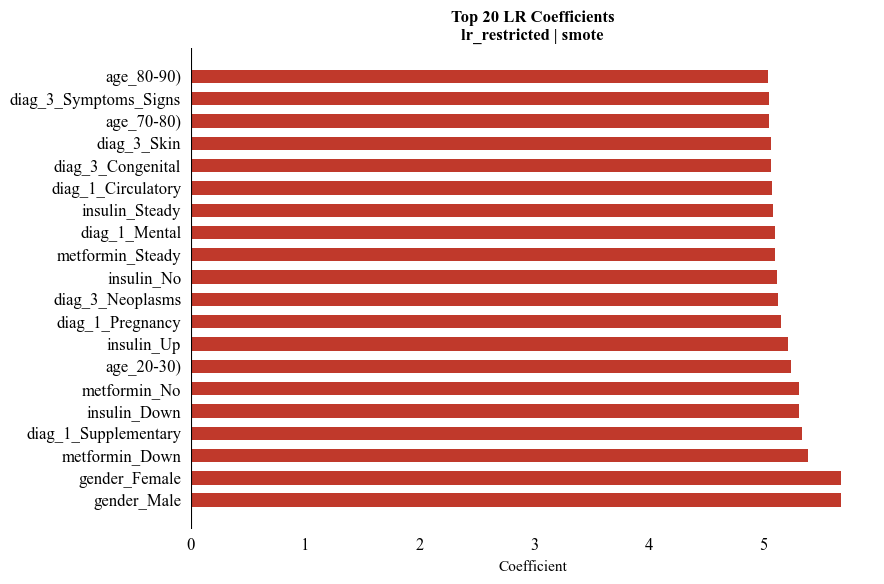


  EVALUATING: Lr Restricted (smote)
AUROC:     0.5747
F1:        0.0000
Precision: 0.0000
Recall:    0.0000
AUC-PR:    0.1415

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     17825
    Readmitted       0.00      0.00      0.00      2312

      accuracy                           0.89     20137
     macro avg       0.44      0.50      0.47     20137
  weighted avg       0.78      0.89      0.83     20137



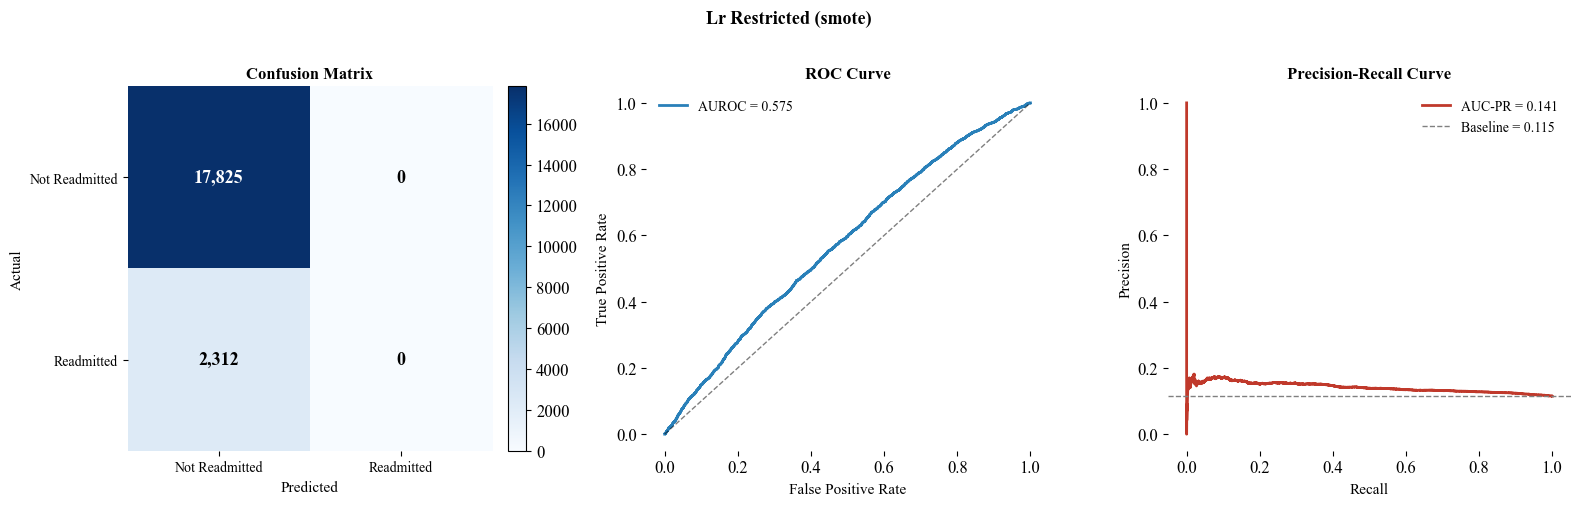

✓ Saved: eval_Lr_Restricted_smote.png

───────────────────────────────────────────────────────
LOGISTIC REGRESSION — LR_ADJUSTED | SMOTE
───────────────────────────────────────────────────────

Running 5-fold CV...
  CV roc_auc: [0.9539 0.9513 0.9538 0.9536 0.9544] | Mean: 0.9534 ± 0.0011


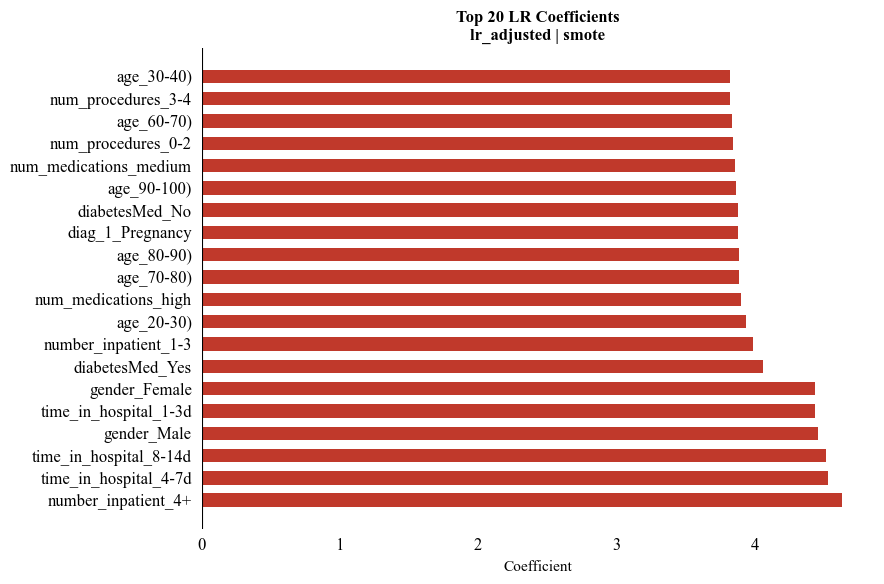


  EVALUATING: Lr Adjusted (smote)
AUROC:     0.6355
F1:        0.0009
Precision: 0.1667
Recall:    0.0004
AUC-PR:    0.1914

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     17825
    Readmitted       0.17      0.00      0.00      2312

      accuracy                           0.88     20137
     macro avg       0.53      0.50      0.47     20137
  weighted avg       0.80      0.88      0.83     20137



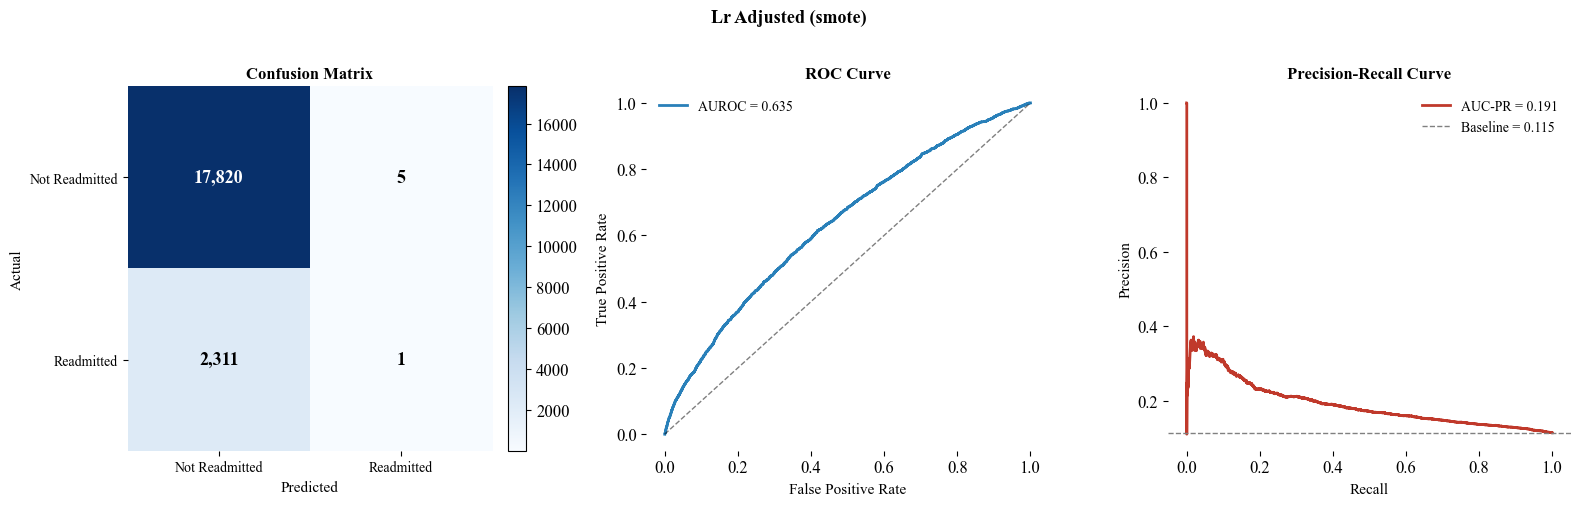

✓ Saved: eval_Lr_Adjusted_smote.png

───────────────────────────────────────────────────────
RANDOM FOREST | BALANCED
───────────────────────────────────────────────────────
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}
Best CV AUROC: 0.6550


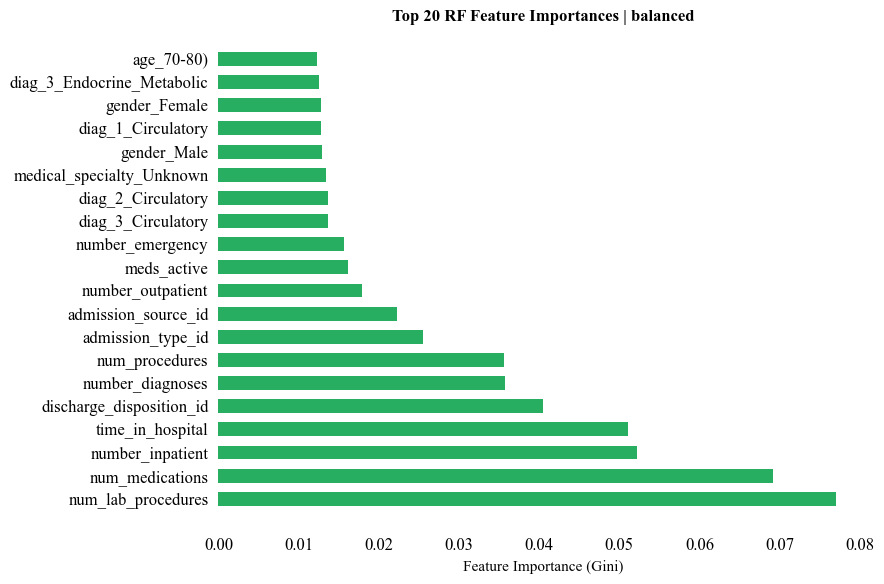


  EVALUATING: Random Forest (balanced)
AUROC:     0.6606
F1:        0.0094
Precision: 0.4583
Recall:    0.0048
AUC-PR:    0.2122

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     17825
    Readmitted       0.46      0.00      0.01      2312

      accuracy                           0.89     20137
     macro avg       0.67      0.50      0.47     20137
  weighted avg       0.84      0.89      0.83     20137



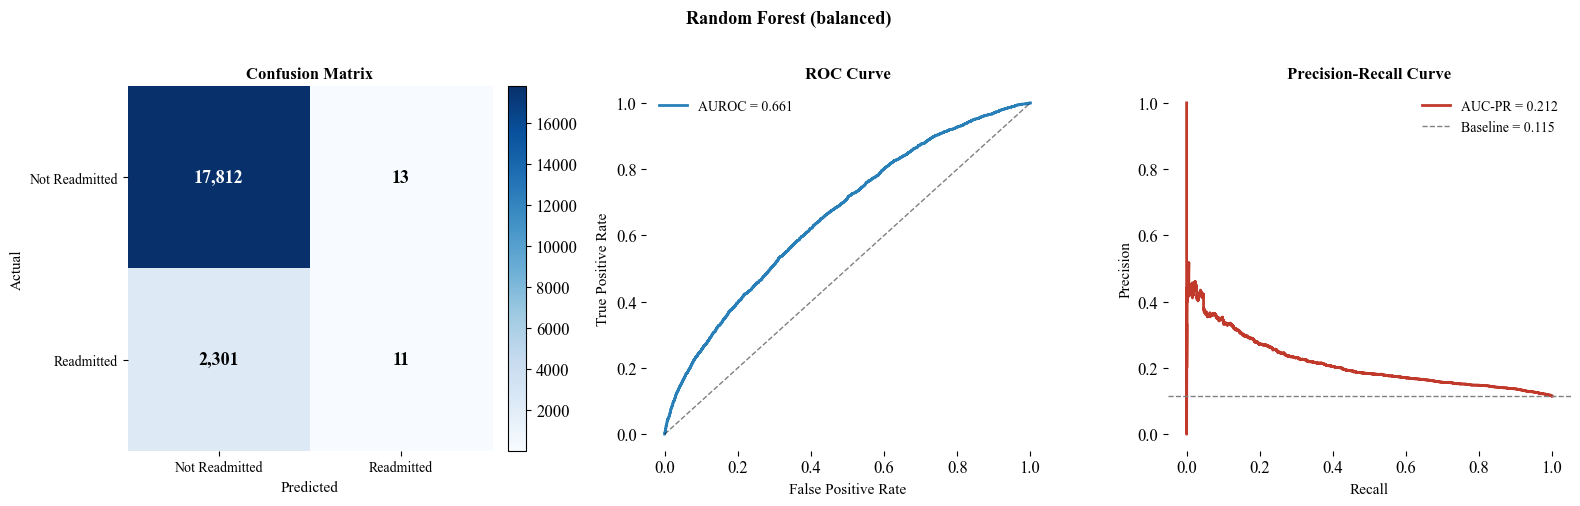

✓ Saved: eval_Random_Forest_balanced.png

───────────────────────────────────────────────────────
RANDOM FOREST | SMOTE
───────────────────────────────────────────────────────
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Best CV AUROC: 0.9628


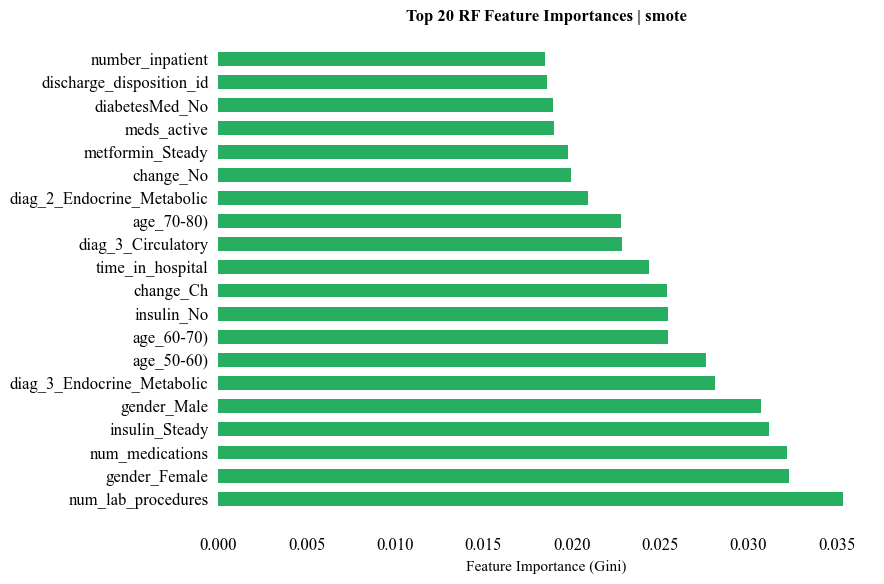


  EVALUATING: Random Forest (smote)
AUROC:     0.6043
F1:        0.0094
Precision: 0.5500
Recall:    0.0048
AUC-PR:    0.1694

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     17825
    Readmitted       0.55      0.00      0.01      2312

      accuracy                           0.89     20137
     macro avg       0.72      0.50      0.47     20137
  weighted avg       0.85      0.89      0.83     20137



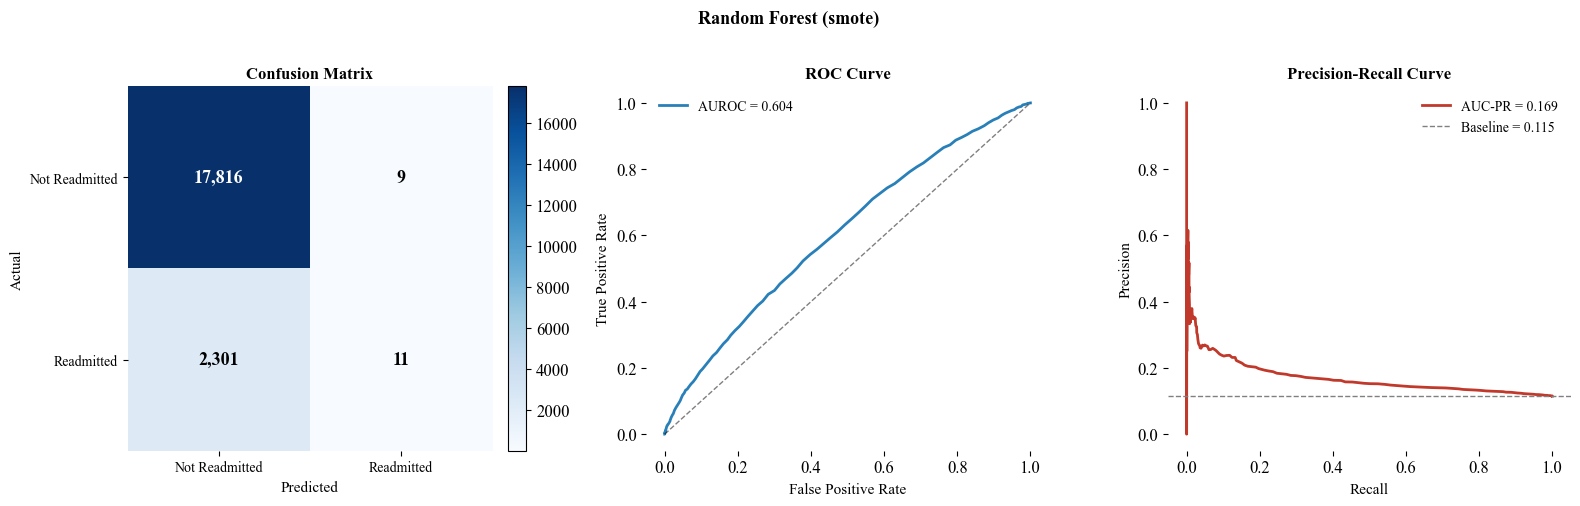

✓ Saved: eval_Random_Forest_smote.png

───────────────────────────────────────────────────────
XGBOOST | BALANCED
───────────────────────────────────────────────────────
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV AUROC: nan


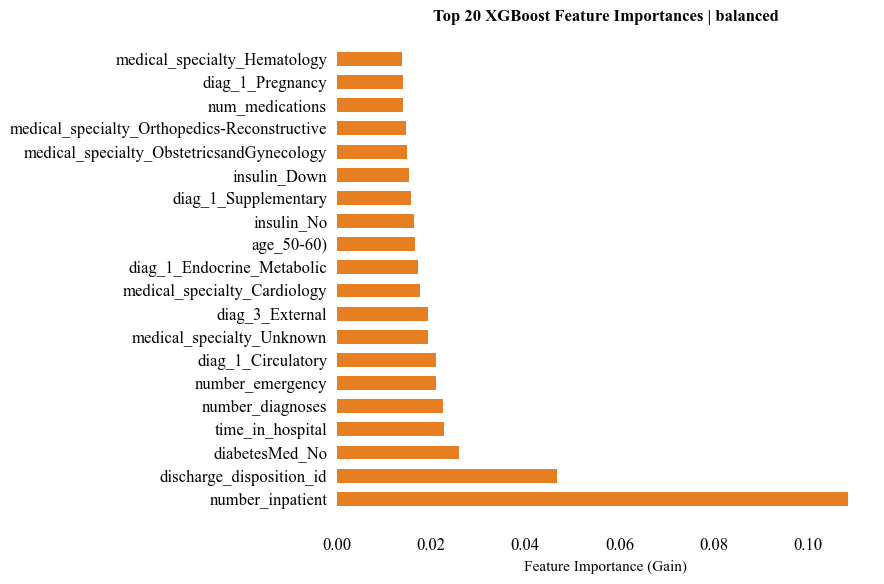

Computing SHAP values (this may take a moment)...


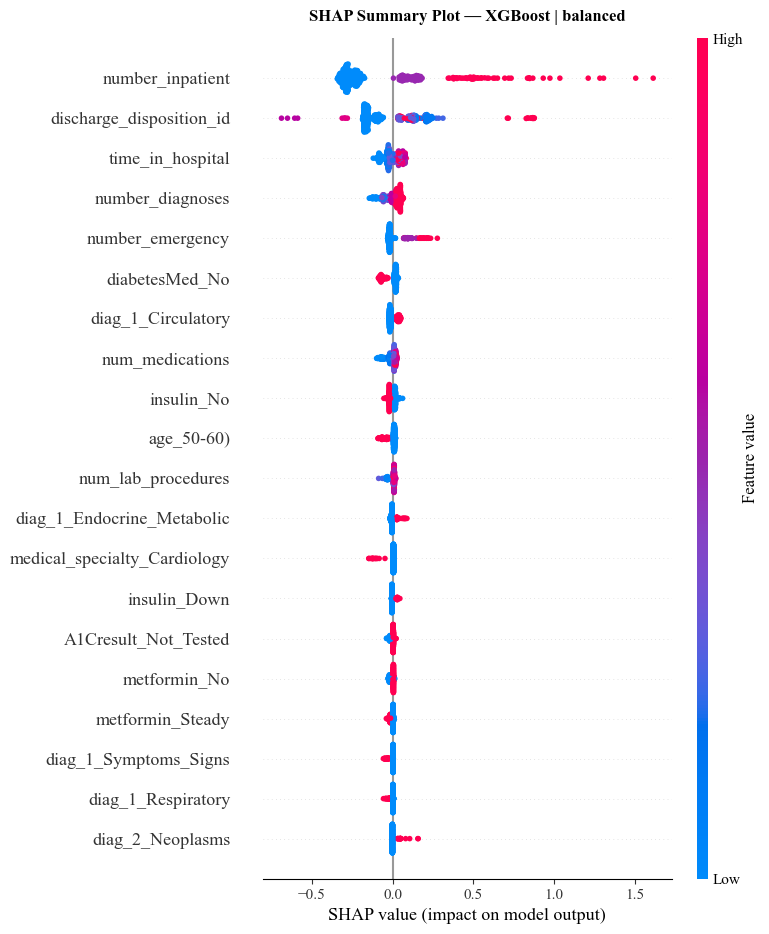

✓ Saved: shap_xgb_balanced.png

  EVALUATING: XGBoost (balanced)
AUROC:     0.6769
F1:        0.2784
Precision: 0.1798
Recall:    0.6159
AUC-PR:    0.2237

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.93      0.64      0.75     17825
    Readmitted       0.18      0.62      0.28      2312

      accuracy                           0.63     20137
     macro avg       0.55      0.63      0.52     20137
  weighted avg       0.84      0.63      0.70     20137



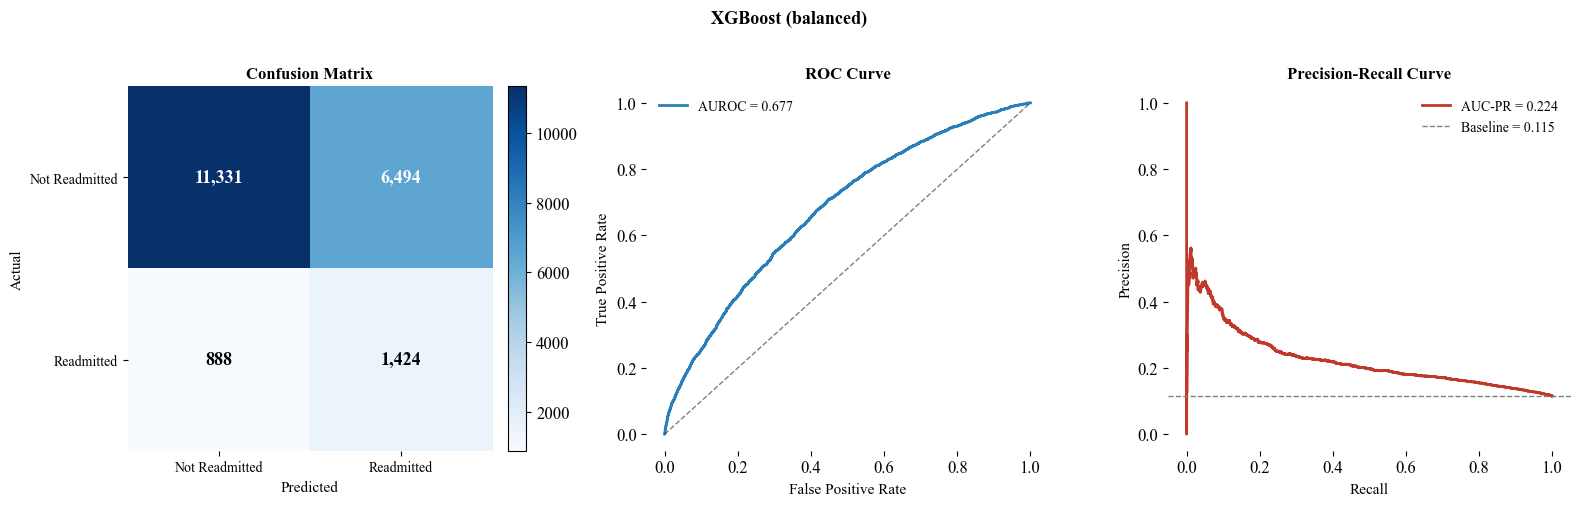

✓ Saved: eval_XGBoost_balanced.png

───────────────────────────────────────────────────────
XGBOOST | SMOTE
───────────────────────────────────────────────────────
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV AUROC: nan


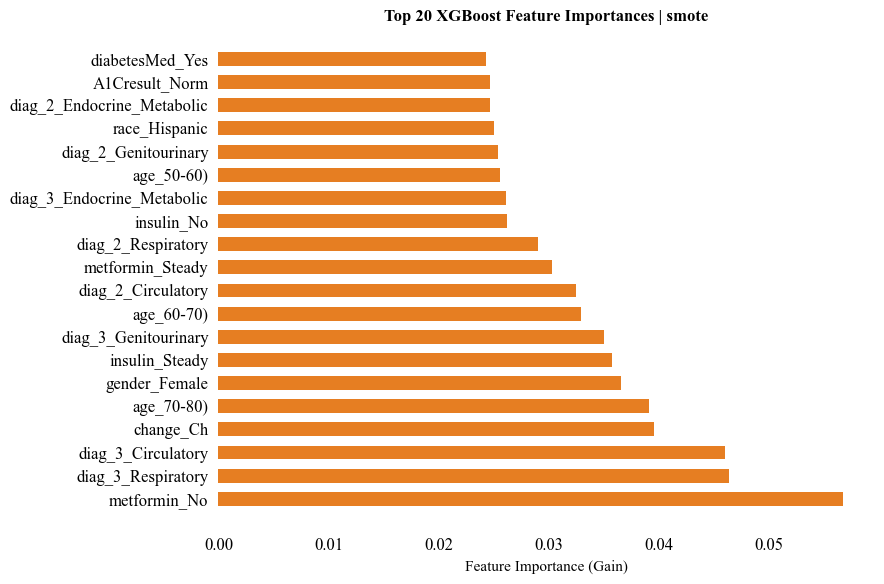

Computing SHAP values (this may take a moment)...


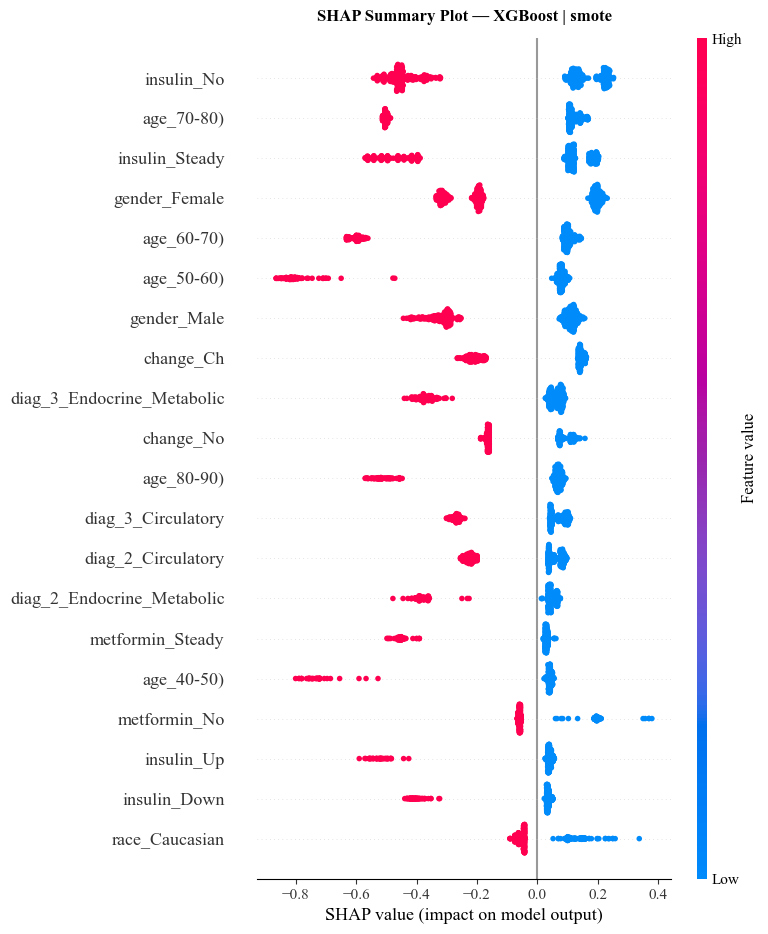

✓ Saved: shap_xgb_smote.png

  EVALUATING: XGBoost (smote)
AUROC:     0.5759
F1:        0.0747
Precision: 0.2199
Recall:    0.0450
AUC-PR:    0.1512

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.89      0.98      0.93     17825
    Readmitted       0.22      0.04      0.07      2312

      accuracy                           0.87     20137
     macro avg       0.55      0.51      0.50     20137
  weighted avg       0.81      0.87      0.83     20137



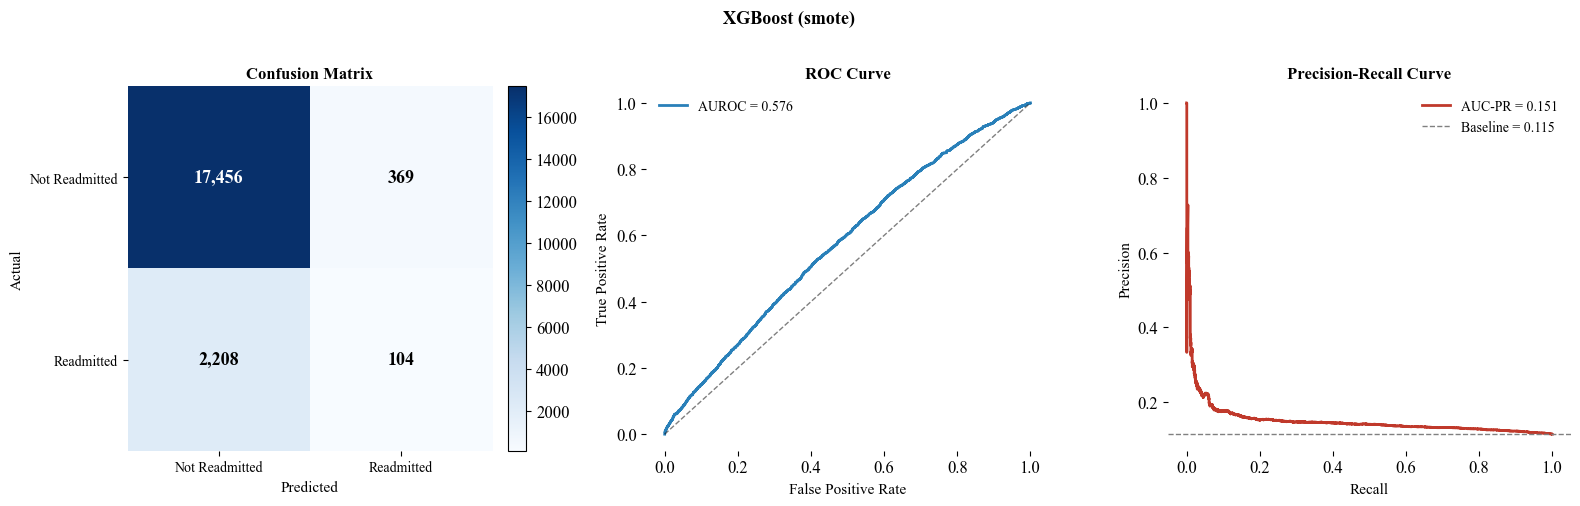

✓ Saved: eval_XGBoost_smote.png

───────────────────────────────────────────────────────
NEURAL NETWORK | BALANCED
───────────────────────────────────────────────────────
bool     166
int64     14
Name: count, dtype: int64


2026-04-02 18:03:25.849668: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2026-04-02 18:03:25.849919: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-04-02 18:03:25.849936: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
2026-04-02 18:03:25.849955: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-02 18:03:25.849966: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/50


2026-04-02 18:03:27.132794: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


264/264 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - AUC: 0.5689 - Precision: 0.1344 - Recall: 0.5368 - loss: 1.3762 - val_AUC: 0.6328 - val_Precision: 0.1506 - val_Recall: 0.5474 - val_loss: 0.6820
Epoch 2/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - AUC: 0.5944 - Precision: 0.1440 - Recall: 0.5411 - loss: 1.2552 - val_AUC: 0.6413 - val_Precision: 0.1548 - val_Recall: 0.5339 - val_loss: 0.6802
Epoch 3/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - AUC: 0.6033 - Precision: 0.1494 - Recall: 0.5310 - loss: 1.2283 - val_AUC: 0.6393 - val_Precision: 0.1537 - val_Recall: 0.5450 - val_loss: 0.6876
Epoch 4/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - AUC: 0.6202 - Precision: 0.1584 - Recall: 0.5469 - loss: 1.2023 - val_AUC: 0.6343 - val_Precision: 0.1529 - val_Recall: 0.5227 - val_loss: 0.6860
Epoch 5/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - AUC: 0.6306 - Precision: 0.1637 - Recall: 0.5423 - loss: 1.1915 - val_AUC: 0.6220 - val_Precision: 0.1510 - val_Recall: 0.4988 - val_loss: 0.6840
Epoch 

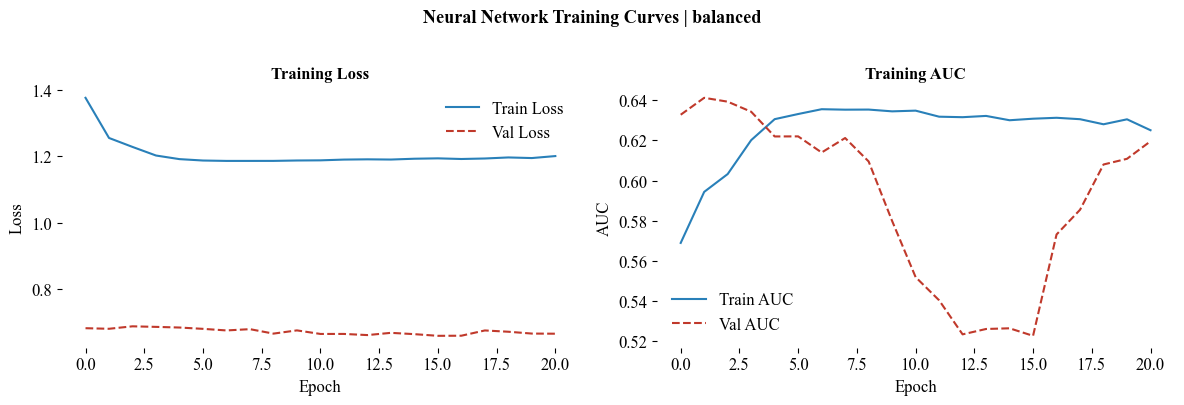


  EVALUATING: Neural Network (balanced)
630/630 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
AUROC:     0.5332
F1:        0.2004
Precision: 0.1303
Recall:    0.4338
AUC-PR:    0.1606

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.89      0.62      0.74     17825
    Readmitted       0.13      0.43      0.20      2312

      accuracy                           0.60     20137
     macro avg       0.51      0.53      0.47     20137
  weighted avg       0.81      0.60      0.67     20137



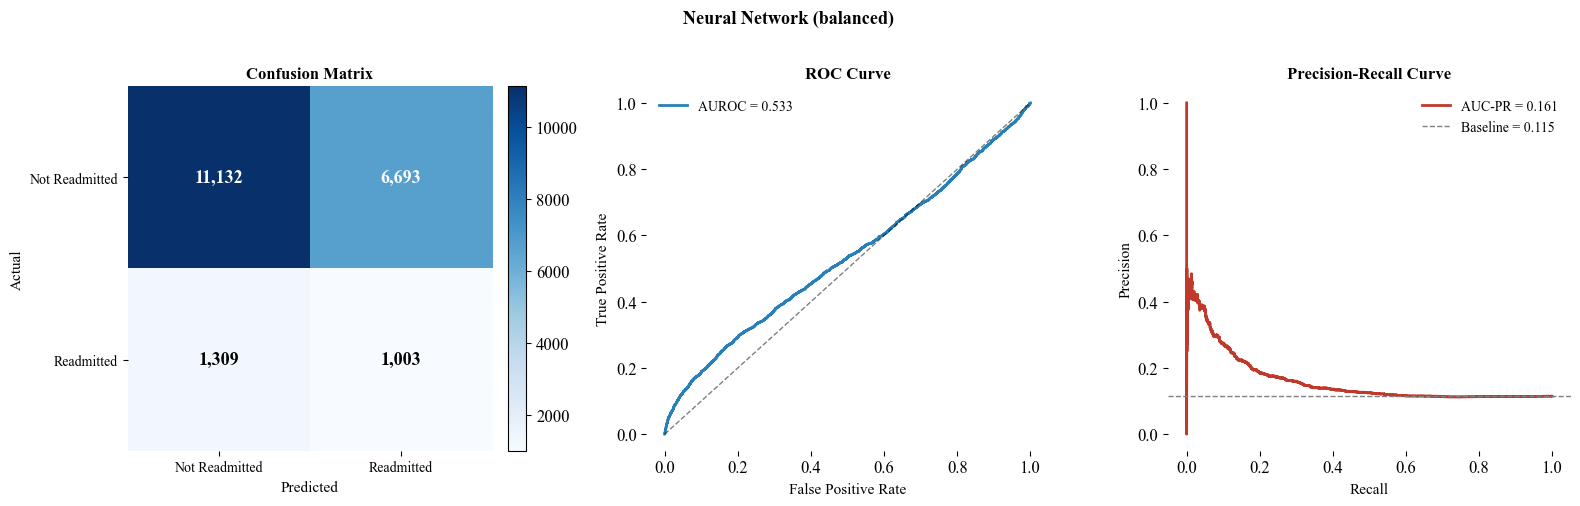

✓ Saved: eval_Neural_Network_balanced.png

───────────────────────────────────────────────────────
NEURAL NETWORK | SMOTE
───────────────────────────────────────────────────────
bool     166
int64     14
Name: count, dtype: int64
Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - AUC: 0.8956 - Precision: 0.8744 - Recall: 0.7703 - loss: 0.3755 - val_AUC: 0.0000e+00 - val_Precision: 1.0000 - val_Recall: 0.9995 - val_loss: 0.0102
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - AUC: 0.9170 - Precision: 0.9615 - Recall: 0.8118 - loss: 0.2872 - val_AUC: 0.0000e+00 - val_Precision: 1.0000 - val_Recall: 0.9914 - val_loss: 0.0302
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - AUC: 0.9196 - Precision: 0.9731 - Recall: 0.8139 - loss: 0.2709 - val_AUC: 0.0000e+00 - val_Precision: 1.0000 - val_Recall: 0.9913 - val_loss: 0.0326
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - AUC: 0.9209 - Precision: 0.9779 - Recall: 0.8162 - loss: 0.2628 - val_AUC: 0.0000e+00 - val_Prec

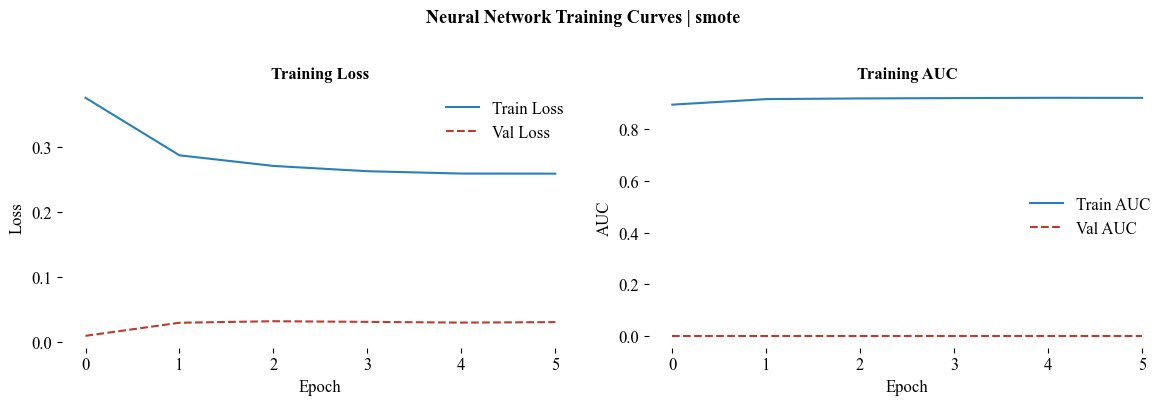


  EVALUATING: Neural Network (smote)
630/630 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
AUROC:     0.5926
F1:        0.2264
Precision: 0.1425
Recall:    0.5506
AUC-PR:    0.1623

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.91      0.57      0.70     17825
    Readmitted       0.14      0.55      0.23      2312

      accuracy                           0.57     20137
     macro avg       0.52      0.56      0.46     20137
  weighted avg       0.82      0.57      0.65     20137



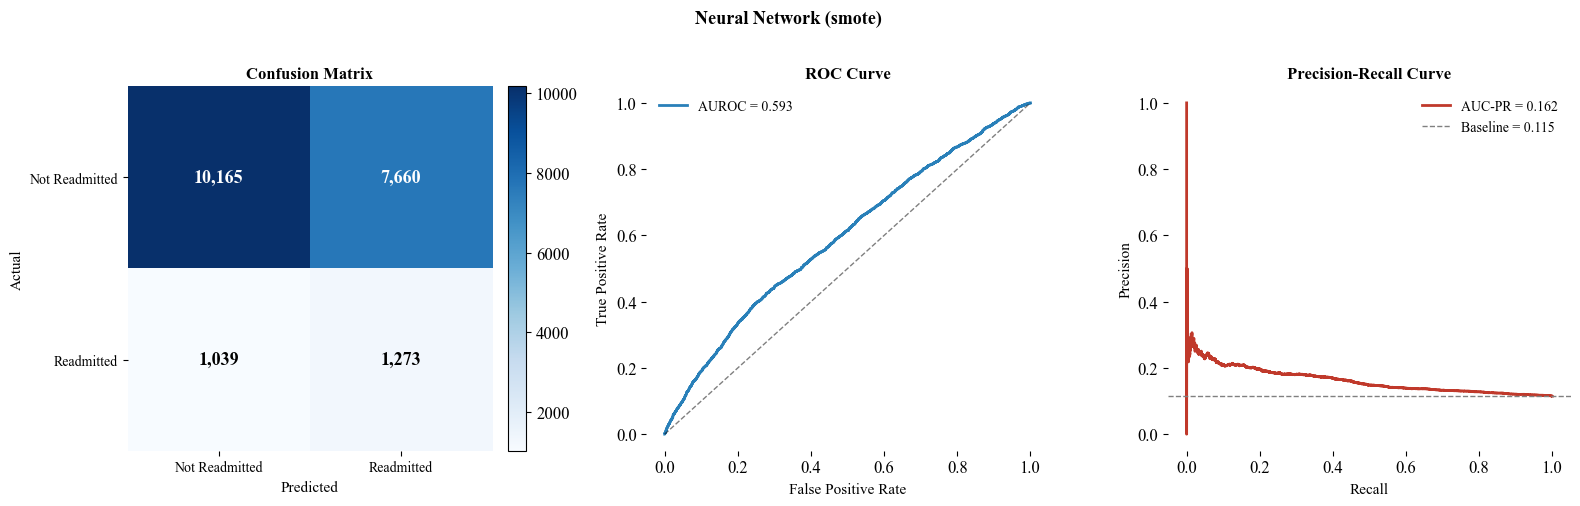

✓ Saved: eval_Neural_Network_smote.png


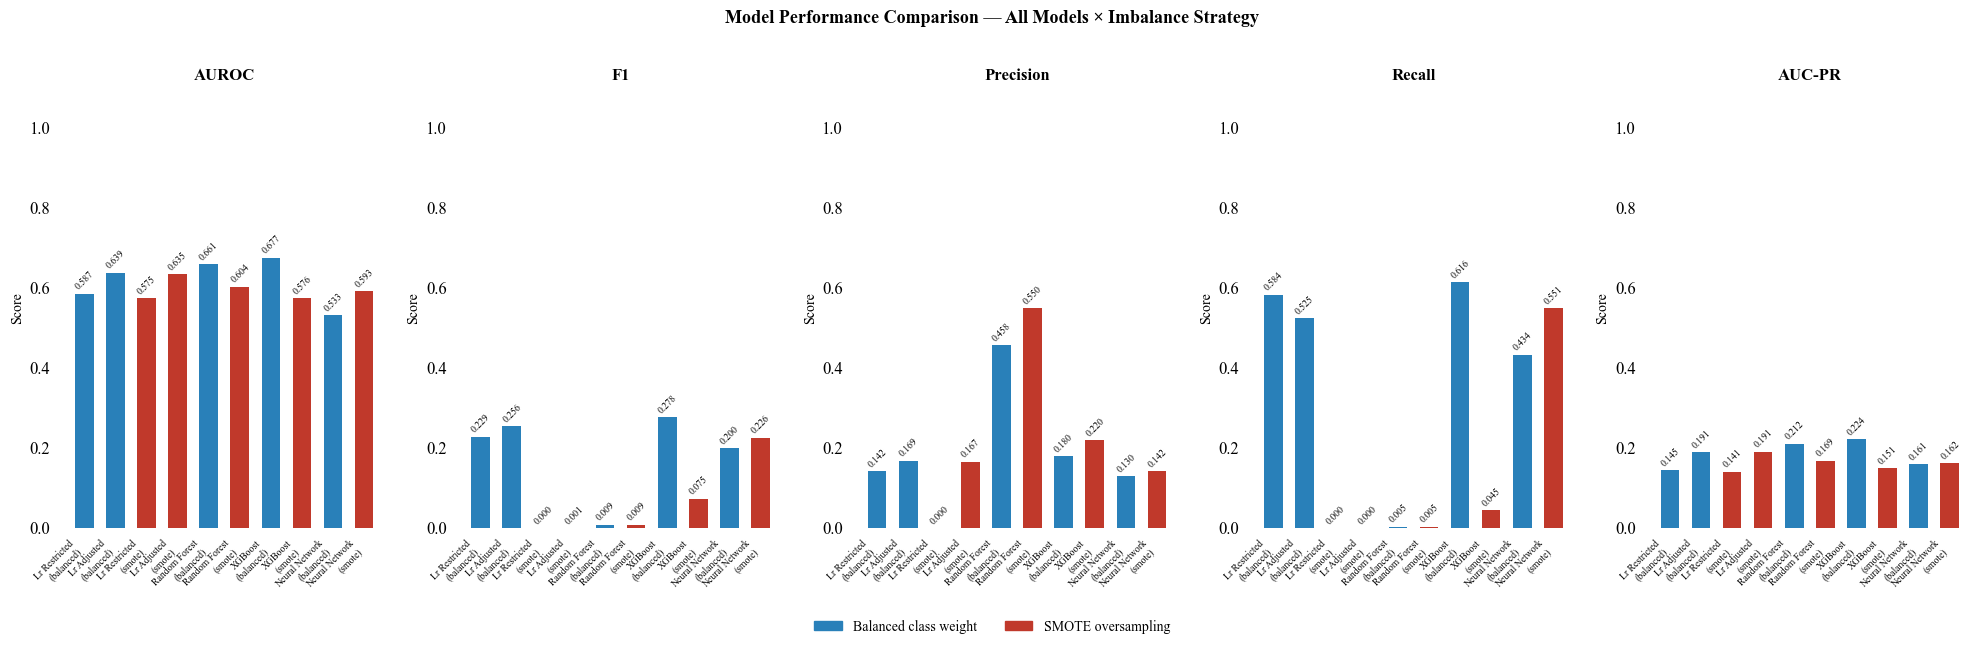

✓ Saved: model_comparison.png

 Saved: model_results.csv
 Saved: model_results.xlsx
 Saved: model_results.docx

PIPELINE COMPLETE
                    Model  AUROC     F1  Precision  Recall  AUC-PR
       XGBoost (balanced) 0.6769 0.2784     0.1798  0.6159  0.2237
 Random Forest (balanced) 0.6606 0.0094     0.4583  0.0048  0.2122
   Lr Adjusted (balanced) 0.6390 0.2559     0.1692  0.5247  0.1905
      Lr Adjusted (smote) 0.6355 0.0009     0.1667  0.0004  0.1914
    Random Forest (smote) 0.6043 0.0094     0.5500  0.0048  0.1694
   Neural Network (smote) 0.5926 0.2264     0.1425  0.5506  0.1623
 Lr Restricted (balanced) 0.5866 0.2290     0.1424  0.5843  0.1450
          XGBoost (smote) 0.5759 0.0747     0.2199  0.0450  0.1512
    Lr Restricted (smote) 0.5747 0.0000     0.0000  0.0000  0.1415
Neural Network (balanced) 0.5332 0.2004     0.1303  0.4338  0.1606


In [11]:
# ═══════════════════════════════════════════════════════════════
# COOMPLETE ML PIPELINE — DIABETES 30-DAY READMISSION PREDICTION;
# ═══════════════════════════════════════════════════════════════

# Pipeline designed with Claude ai to streamline running process

# Global configs for all movel
CONFIG = {
    'random_state':        42,
    'cv_folds':            5,
    'winsorize_limits':    [0.01, 0.01],
    'imbalance_strategies': ['balanced', 'smote'],
    'models_to_run':       ['lr_restricted', 'lr_adjusted', 'rf', 'xgboost', 'nn'], 
    'lr_max_iter':         1000,
    'rf_param_grid':       {'n_estimators': [100, 300], 'max_depth': [5, 10, None],
                            'min_samples_split': [2, 5]},
    'xgb_param_grid':      {'n_estimators': [100, 300], 'max_depth': [3, 6],
                            'learning_rate': [0.05, 0.1], 'subsample': [0.8, 1.0]},
    'nn_epochs':           50,
    'nn_batch_size':       256,
}

# Non-linear features identified by Box-Tidwell (p < 0.05)
NON_LINEAR_FEATURES = [
    'discharge_disposition_id', 'admission_source_id',
    'time_in_hospital', 'num_procedures', 'num_medications',
    'number_outpatient', 'number_emergency', 'number_inpatient'
]

# STEP 1 — ICD-9 CATEGORY MAPPING

def map_icd9(code):
    """Map ICD-9 code string to broad disease category."""
    if pd.isna(code) or code == 'None':
        return 'None'
    code = str(code).strip()
    if code.startswith('V'):
        return 'Supplementary'
    if code.startswith('E'):
        return 'External'
    try:
        c = float(code.split('.')[0])
        if   c < 140:  return 'Infectious'
        elif c < 240:  return 'Neoplasms'
        elif c < 280:  return 'Endocrine_Metabolic'
        elif c < 290:  return 'Blood'
        elif c < 320:  return 'Mental'
        elif c < 390:  return 'Nervous'
        elif c < 460:  return 'Circulatory'
        elif c < 520:  return 'Respiratory'
        elif c < 580:  return 'Digestive'
        elif c < 630:  return 'Genitourinary'
        elif c < 680:  return 'Pregnancy'
        elif c < 710:  return 'Skin'
        elif c < 740:  return 'Musculoskeletal'
        elif c < 780:  return 'Congenital'
        elif c < 800:  return 'Symptoms_Signs'
        else:          return 'Injury'
    except:
        return 'Other'

print("Mapping ICD-9 codes to disease categories...")
for diag_col in ['diag_1', 'diag_2', 'diag_3']:
    if diag_col in full_dataset.columns:
        full_dataset[diag_col] = full_dataset[diag_col].apply(map_icd9)
print("ICD-9 mapping complete")
print(full_dataset['diag_1'].value_counts().head(10))


# STEP 2 — PREPARE FEATURES AND TARGET


drop_cols = ['readmitted']
if 'encounter_id' in full_dataset.columns: drop_cols.append('encounter_id')
if 'patient_nbr'  in full_dataset.columns: drop_cols.append('patient_nbr')

X_raw = full_dataset.drop(columns=drop_cols)
y     = full_dataset['readmitted']

# One-hot encode all categorical features
cat_cols_ohe = X_raw.select_dtypes(include='object').columns.tolist()
X_ohe        = pd.get_dummies(X_raw, columns=cat_cols_ohe, drop_first=False)
X_ohe        = X_ohe.fillna(0)

def clean_feature_names(df):
    """Remove characters XGBoost doesn't allow in feature names: [ ] <"""
    df.columns = (df.columns
                    .str.replace('[', '', regex=False)
                    .str.replace(']', '', regex=False)
                    .str.replace('<', 'lt', regex=False)
                    .str.replace('>', 'gt', regex=False)
                    .str.replace(' ', '_', regex=False))
    return df
X_ohe = clean_feature_names(X_ohe)

print(f"\n Final feature matrix: {X_ohe.shape[0]:,} rows  {X_ohe.shape[1]} features")


# STEP 3 — TRAIN / TEST SPLIT (patient-level, stratified)

from sklearn.model_selection import StratifiedGroupKFold

groups   = full_dataset['patient_nbr'] if 'patient_nbr' in full_dataset.columns \
           else pd.Series(range(len(full_dataset)))
sgkf     = StratifiedGroupKFold(n_splits=5, shuffle=True,
                                random_state=CONFIG['random_state'])
train_idx, test_idx = next(sgkf.split(X_ohe, y, groups=groups))

X_trainval = X_ohe.iloc[train_idx].reset_index(drop=True)
X_test     = X_ohe.iloc[test_idx].reset_index(drop=True)
y_trainval = y.iloc[train_idx].reset_index(drop=True)
y_test     = y.iloc[test_idx].reset_index(drop=True)

print(f"Train+Val: {len(X_trainval):,} | Test: {len(X_test):,}")
print(f"Class balance — Train: {y_trainval.mean()*100:.2f}% | Test: {y_test.mean()*100:.2f}%")


# STEP 4 — PREPROCESSING VARIANTS
num_cols_all = X_ohe.select_dtypes(include=['int64', 'float64']).columns.tolist()

def winsorize_df(X_tr, X_te, cols, limits):
    X_tr, X_te = X_tr.copy(), X_te.copy()
    for col in cols:
        if col in X_tr.columns:
            lo = np.percentile(X_tr[col], limits[0]*100)
            hi = np.percentile(X_tr[col], (1 - limits[1])*100)
            X_tr[col] = X_tr[col].clip(lo, hi)
            X_te[col] = X_te[col].clip(lo, hi)
    return X_tr, X_te

def scale_df(X_tr, X_te, cols):
    X_tr, X_te = X_tr.copy(), X_te.copy()
    scaler = StandardScaler()
    X_tr[cols] = scaler.fit_transform(X_tr[cols])
    X_te[cols]  = scaler.transform(X_te[cols])
    return X_tr, X_te, scaler

def bin_nonlinear_features(X):
    """Bin non-linear continuous features into clinically meaningful intervals."""
    X = X.copy()
    bin_map = {
        'time_in_hospital':    ([0, 3, 7, 14],    ['1-3d', '4-7d', '8-14d']),
        'num_medications':     ([0, 10, 20, 81],   ['low', 'medium', 'high']),
        'num_procedures':      ([0, 2, 4, 6],      ['0-2', '3-4', '5-6']),
        'number_outpatient':   ([0, 1, 5, 42],     ['0', '1-5', '6+']),
        'number_emergency':    ([0, 1, 5, 76],     ['0', '1-5', '6+']),
        'number_inpatient':    ([0, 1, 3, 21],     ['0', '1-3', '4+']),
    }
    for col, (bins, labels) in bin_map.items():
        if col in X.columns:
            X[col] = pd.cut(X[col], bins=bins, labels=labels,
                            include_lowest=True).astype(str)
    # Re-encode any newly created categoricals
    new_cats = X.select_dtypes(include='object').columns.tolist()
    if new_cats:
        X = pd.get_dummies(X, columns=new_cats, drop_first=False)
    return X

# ── LR Restricted: drop non-linear feature columns ──
nl_cols_ohe = [c for c in X_ohe.columns
               if any(c.startswith(nl) for nl in NON_LINEAR_FEATURES)]
X_lr_r_train = X_trainval.drop(columns=nl_cols_ohe, errors='ignore')
X_lr_r_test  = X_test.drop(columns=nl_cols_ohe, errors='ignore')

# ── LR Adjusted: bin non-linear features ──
X_lr_a_train_raw = bin_nonlinear_features(X_trainval)
X_lr_a_test_raw  = bin_nonlinear_features(X_test)
# Align columns after binning
X_lr_a_train_raw, X_lr_a_test_raw = (
    X_lr_a_train_raw.align(X_lr_a_test_raw, join='left', axis=1, fill_value=0))

print(f"\n LR Restricted features:  {X_lr_r_train.shape[1]}")
print(f" LR Adjusted features:    {X_lr_a_train_raw.shape[1]}")
print(f" RF/XGBoost/NN features:  {X_trainval.shape[1]}")


# STEP 5 — HELPER: EVALUATE AND PLOT
results_store = {}  # stores all metric results for final comparison
def evaluate_model(model_name, strategy, model, X_tr, X_te, y_tr, y_te,
                   feature_names=None, is_nn=False):
    """Run full evaluation suite and store results."""
    tag = f"{model_name} ({strategy})"
    print(f"\n{'='*55}")
    print(f"  EVALUATING: {tag}")
    print(f"{'='*55}")

    # Predictions
    if is_nn:
        y_prob = model.predict(X_te).ravel()
        y_pred = (y_prob >= 0.5).astype(int)
    else:
        y_prob = model.predict_proba(X_te)[:, 1]
        y_pred = model.predict(X_te)

    # Metrics
    auroc    = roc_auc_score(y_te, y_prob)
    f1       = f1_score(y_te, y_pred)
    prec     = precision_score(y_te, y_pred)
    rec      = recall_score(y_te, y_pred)
    auc_pr   = average_precision_score(y_te, y_prob)
    cm       = confusion_matrix(y_te, y_pred)
    cr       = classification_report(y_te, y_pred,
                                      target_names=['Not Readmitted', 'Readmitted'])

    print(f"AUROC:     {auroc:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"AUC-PR:    {auc_pr:.4f}")
    print(f"\nClassification Report:\n{cr}")

    results_store[tag] = {
        'AUROC': round(auroc, 4), 'F1': round(f1, 4),
        'Precision': round(prec, 4), 'Recall': round(rec, 4),
        'AUC-PR': round(auc_pr, 4)
    }

    # ── Figures ──
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # 1. Confusion Matrix
    ax = axes[0]
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Not Readmitted', 'Readmitted'], fontsize=10)
    ax.set_yticklabels(['Not Readmitted', 'Readmitted'], fontsize=10)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                    fontsize=13, fontweight='bold',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for spine in ax.spines.values(): spine.set_visible(False)

    # 2. ROC Curve
    ax = axes[1]
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    ax.plot(fpr, tpr, color='#2980B9', lw=2, label=f'AUROC = {auroc:.3f}')
    ax.plot([0,1], [0,1], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title('ROC Curve', fontsize=12, fontweight='bold')
    ax.legend(frameon=False, fontsize=10)
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.grid(False)

    # 3. Precision-Recall Curve
    ax = axes[2]
    precision_c, recall_c, _ = precision_recall_curve(y_te, y_prob)
    baseline = y_te.mean()
    ax.plot(recall_c, precision_c, color='#C0392B', lw=2,
            label=f'AUC-PR = {auc_pr:.3f}')
    ax.axhline(y=baseline, linestyle='--', color='gray', lw=1,
               label=f'Baseline = {baseline:.3f}')
    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
    ax.legend(frameon=False, fontsize=10)
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.grid(False)

    safe_tag = tag.replace(' ', '_').replace('(', '').replace(')', '')
    plt.suptitle(f'{tag}', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'Output/eval_{safe_tag}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: eval_{safe_tag}.png")

    return y_prob, y_pred


# STEP 6 — CROSS VALIDATION HELPER


def run_cv(model, X, y, cv, scoring='roc_auc'):
    skf    = StratifiedKFold(n_splits=cv, shuffle=True,
                              random_state=CONFIG['random_state'])
    scores = cross_val_score(model, X, y, cv=skf, scoring=scoring, n_jobs=-1)
    print(f"  CV {scoring}: {scores.round(4)} | Mean: {scores.mean():.4f} ± {scores.std():.4f}")
    return scores


# STEP 7 — LOGISTIC REGRESSION


for strategy in CONFIG['imbalance_strategies']:
    for lr_type in ['lr_restricted', 'lr_adjusted']:
        if lr_type not in CONFIG['models_to_run']:
            continue

        print(f"\n{'─'*55}")
        print(f"LOGISTIC REGRESSION — {lr_type.upper()} | {strategy.upper()}")
        print(f"{'─'*55}")

        X_tr = X_lr_r_train.copy() if lr_type == 'lr_restricted' else X_lr_a_train_raw.copy()
        X_te = X_lr_r_test.copy()  if lr_type == 'lr_restricted' else X_lr_a_test_raw.copy()

        # Winsorize + scale for LR
        num_lr = X_tr.select_dtypes(include=['int64', 'float64']).columns.tolist()
        X_tr, X_te = winsorize_df(X_tr, X_te, num_lr, CONFIG['winsorize_limits'])
        X_tr, X_te, _ = scale_df(X_tr, X_te, num_lr)

        if strategy == 'smote':
            sm          = SMOTE(random_state=CONFIG['random_state'])
            X_tr_s, y_tr_s = sm.fit_resample(X_tr, y_trainval)
            cw          = None
        else:
            X_tr_s, y_tr_s = X_tr, y_trainval
            cw          = 'balanced'

        lr_model = LogisticRegression(
            class_weight=cw, max_iter=CONFIG['lr_max_iter'],
            random_state=CONFIG['random_state'], solver='lbfgs', n_jobs=-1
        )

        print("\nRunning 5-fold CV...")
        run_cv(lr_model, X_tr_s, y_tr_s, CONFIG['cv_folds'])

        lr_model.fit(X_tr_s, y_tr_s)

        # Coefficient plot
        coef_df = pd.DataFrame({
            'Feature': X_tr.columns,
            'Coefficient': lr_model.coef_[0]
        }).sort_values('Coefficient', key=abs, ascending=False).head(20)

        fig, ax = plt.subplots(figsize=(9, 6))
        colors_c = ['#C0392B' if c > 0 else '#2980B9' for c in coef_df['Coefficient']]
        ax.barh(coef_df['Feature'], coef_df['Coefficient'],
                color=colors_c, edgecolor='none', height=0.6)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Coefficient', fontsize=11)
        ax.set_title(f'Top 20 LR Coefficients\n{lr_type} | {strategy}',
                     fontsize=12, fontweight='bold')
        for spine in ax.spines.values(): spine.set_visible(False)
        ax.grid(False)
        ax.xaxis.set_ticks_position('none')
        ax.yaxis.set_ticks_position('none')
        safe = f"{lr_type}_{strategy}"
        plt.tight_layout()
        plt.savefig(f'Output/coef_{safe}.png', dpi=300, bbox_inches='tight')
        plt.show()

        evaluate_model(lr_type.replace('_', ' ').title(), strategy,
                       lr_model, X_tr, X_te, y_trainval, y_test)


# STEP 8 — RANDOM FOREST


if 'rf' in CONFIG['models_to_run']:
    from sklearn.model_selection import GridSearchCV

    for strategy in CONFIG['imbalance_strategies']:
        print(f"\n{'─'*55}")
        print(f"RANDOM FOREST | {strategy.upper()}")
        print(f"{'─'*55}")

        if strategy == 'smote':
            sm             = SMOTE(random_state=CONFIG['random_state'])
            X_tr_s, y_tr_s = sm.fit_resample(X_trainval, y_trainval)
            cw             = None
        else:
            X_tr_s, y_tr_s = X_trainval, y_trainval
            cw             = 'balanced'

        rf_base = RandomForestClassifier(
            class_weight=cw, random_state=CONFIG['random_state'], n_jobs=-1
        )
        skf = StratifiedKFold(n_splits=CONFIG['cv_folds'], shuffle=True,
                               random_state=CONFIG['random_state'])
        gs  = GridSearchCV(rf_base, CONFIG['rf_param_grid'],
                           cv=skf, scoring='roc_auc', n_jobs=-1, verbose=1)
        gs.fit(X_tr_s, y_tr_s)

        print(f"\nBest params: {gs.best_params_}")
        print(f"Best CV AUROC: {gs.best_score_:.4f}")

        rf_model = gs.best_estimator_

        # Feature importance plot
        imp_df = pd.DataFrame({
            'Feature':    X_trainval.columns,
            'Importance': rf_model.feature_importances_
        }).sort_values('Importance', ascending=False).head(20)

        fig, ax = plt.subplots(figsize=(9, 6))
        ax.barh(imp_df['Feature'], imp_df['Importance'],
                color='#27AE60', edgecolor='none', height=0.6)
        ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
        ax.set_title(f'Top 20 RF Feature Importances | {strategy}',
                     fontsize=12, fontweight='bold')
        for spine in ax.spines.values(): spine.set_visible(False)
        ax.grid(False)
        ax.xaxis.set_ticks_position('none')
        ax.yaxis.set_ticks_position('none')
        plt.tight_layout()
        plt.savefig(f'Output/rf_importance_{strategy}.png', dpi=300, bbox_inches='tight')
        plt.show()

        evaluate_model('Random Forest', strategy,
                       rf_model, X_trainval, X_test, y_trainval, y_test)


# STEP 9 — XGBOOST + SHAP


if 'xgboost' in CONFIG['models_to_run']:
    from sklearn.model_selection import GridSearchCV

    scale_pos = (y_trainval == 0).sum() / (y_trainval == 1).sum()

    for strategy in CONFIG['imbalance_strategies']:
        print(f"\n{'─'*55}")
        print(f"XGBOOST | {strategy.upper()}")
        print(f"{'─'*55}")

        if strategy == 'smote':
            sm             = SMOTE(random_state=CONFIG['random_state'])
            X_tr_s, y_tr_s = sm.fit_resample(X_trainval, y_trainval)
            spw            = 1
        else:
            X_tr_s, y_tr_s = X_trainval, y_trainval
            spw            = scale_pos

        xgb_base = XGBClassifier(
            scale_pos_weight=spw, eval_metric='logloss',
            random_state=CONFIG['random_state'],
            use_label_encoder=False, n_jobs=-1
        )
        skf = StratifiedKFold(n_splits=CONFIG['cv_folds'], shuffle=True,
                               random_state=CONFIG['random_state'])
        gs  = GridSearchCV(xgb_base, CONFIG['xgb_param_grid'],
                           cv=skf, scoring='roc_auc', n_jobs=-1, verbose=1)
        gs.fit(X_tr_s, y_tr_s)

        print(f"\nBest params: {gs.best_params_}")
        print(f"Best CV AUROC: {gs.best_score_:.4f}")

        xgb_model = gs.best_estimator_

        # Feature importance plot
        imp_df = pd.DataFrame({
            'Feature':    X_trainval.columns,
            'Importance': xgb_model.feature_importances_
        }).sort_values('Importance', ascending=False).head(20)

        fig, ax = plt.subplots(figsize=(9, 6))
        ax.barh(imp_df['Feature'], imp_df['Importance'],
                color='#E67E22', edgecolor='none', height=0.6)
        ax.set_xlabel('Feature Importance (Gain)', fontsize=11)
        ax.set_title(f'Top 20 XGBoost Feature Importances | {strategy}',
                     fontsize=12, fontweight='bold')
        for spine in ax.spines.values(): spine.set_visible(False)
        ax.grid(False)
        ax.xaxis.set_ticks_position('none')
        ax.yaxis.set_ticks_position('none')
        plt.tight_layout()
        plt.savefig(f'Output/xgb_importance_{strategy}.png', dpi=300, bbox_inches='tight')
        plt.show()

        # ── SHAP Plot ──
        print("Computing SHAP values (this may take a moment)...")
        explainer   = shap.TreeExplainer(xgb_model)
        shap_sample = X_test.sample(min(500, len(X_test)),
                                     random_state=CONFIG['random_state'])
        shap_values = explainer.shap_values(shap_sample)

        fig, ax = plt.subplots(figsize=(10, 7))
        shap.summary_plot(shap_values, shap_sample,
                          plot_type='dot', max_display=20,
                          show=False)
        plt.title(f'SHAP Summary Plot — XGBoost | {strategy}',
                  fontsize=12, fontweight='bold', pad=12)
        plt.tight_layout()
        plt.savefig(f'Output/shap_xgb_{strategy}.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ Saved: shap_xgb_{strategy}.png")

        evaluate_model('XGBoost', strategy,
                       xgb_model, X_trainval, X_test, y_trainval, y_test)


# STEP 10 — NEURAL NETWORK


if 'nn' in CONFIG['models_to_run']:

    for strategy in CONFIG['imbalance_strategies']:
        print(f"\n{'─'*55}")
        print(f"NEURAL NETWORK | {strategy.upper()}")
        print(f"{'─'*55}")

        print(X_trainval.dtypes.value_counts())

        # Winsorize + scale for NN
        num_nn  = X_trainval.select_dtypes(include=['int64', 'float64']).columns.tolist()
        X_tr_nn, X_te_nn = winsorize_df(X_trainval, X_test, num_nn,
                                         CONFIG['winsorize_limits'])
        X_tr_nn, X_te_nn, _ = scale_df(X_tr_nn, X_te_nn, num_nn)
        

        if strategy == 'smote':
            sm              = SMOTE(random_state=CONFIG['random_state'])
            X_tr_s, y_tr_s  = sm.fit_resample(X_tr_nn, y_trainval)
            X_tr_s = np.asarray(X_tr_s).astype(np.float32)
            y_tr_s = np.asarray(y_tr_s).astype(np.float32)
            cw_nn           = None
        else:
            X_tr_s, y_tr_s  = X_tr_nn.values, y_trainval.values
            X_tr_s = np.asarray(X_tr_s).astype(np.float32)
            y_tr_s = np.asarray(y_tr_s).astype(np.float32)
            pos              = (y_trainval == 0).sum() / (y_trainval == 1).sum()
            cw_nn            = {0: 1.0, 1: float(pos)}

        # Build model
        tf.random.set_seed(CONFIG['random_state'])
        n_features = X_tr_nn.shape[1]

        nn_model = Sequential([
            Dense(256, activation='relu', input_shape=(n_features,)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(128, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(64, activation='relu'),
            Dropout(0.2),
            Dense(1, activation='sigmoid')
        ])

        nn_model.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['AUC', 'Precision', 'Recall']
        )

        es = EarlyStopping(monitor='val_loss', patience=5,
                           restore_best_weights=True)

        history = nn_model.fit(
            X_tr_s, y_tr_s,
            validation_split=0.15,
            epochs=CONFIG['nn_epochs'],
            batch_size=CONFIG['nn_batch_size'],
            class_weight=cw_nn,
            callbacks=[es],
            verbose=1
        )

        # Training curves
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(history.history['loss'],     label='Train Loss', color='#2980B9')
        axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#C0392B',
                     linestyle='--')
        axes[0].set_title('Training Loss', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
        axes[0].legend(frameon=False)
        for spine in axes[0].spines.values(): spine.set_visible(False)

        axes[1].plot(history.history['AUC'],     label='Train AUC', color='#2980B9')
        axes[1].plot(history.history['val_AUC'], label='Val AUC',   color='#C0392B',
                     linestyle='--')
        axes[1].set_title('Training AUC', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
        axes[1].legend(frameon=False)
        for spine in axes[1].spines.values(): spine.set_visible(False)

        plt.suptitle(f'Neural Network Training Curves | {strategy}',
                     fontsize=13, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.savefig(f'Output/nn_training_{strategy}.png', dpi=300, bbox_inches='tight')
        plt.show()

        # X_tr_nn_new = np.asarray(X_tr_nn).astype(np.float32)
        # X_te_nn_new = np.asarray(X_te_nn).astype(np.float32)
        evaluate_model('Neural Network', strategy,
                       nn_model, X_tr_nn.values.astype(np.float32), X_te_nn.values.astype(np.float32),
                       y_trainval.values.astype(np.float32), y_test.values.astype(np.float32), is_nn=True)
        


# STEP 11 — FINAL COMPARISON PLOT


metrics   = ['AUROC', 'F1', 'Precision', 'Recall', 'AUC-PR']
model_tags = list(results_store.keys())

fig, axes = plt.subplots(1, len(metrics), figsize=(20, 6))

for ax, metric in zip(axes, metrics):
    vals   = [results_store[m][metric] for m in model_tags]
    colors = ['#2980B9' if 'balanced' in m else '#C0392B' for m in model_tags]
    bars   = ax.bar(range(len(model_tags)), vals, color=colors, edgecolor='none', width=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)
    ax.set_xticks(range(len(model_tags)))
    ax.set_xticklabels([m.replace(' (', '\n(') for m in model_tags],
                        rotation=45, ha='right', fontsize=7)
    ax.set_ylim(0, 1.1)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=10)
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.grid(False)
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')

legend_patches = [
    mpatches.Patch(color='#2980B9', label='Balanced class weight'),
    mpatches.Patch(color='#C0392B', label='SMOTE oversampling'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=2,
           frameon=False, fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Model Performance Comparison — All Models × Imbalance Strategy',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('Output/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: model_comparison.png")


# STEP 12 — EXPORT RESULTS TABLE


results_df = pd.DataFrame(results_store).T.reset_index()
results_df.columns = ['Model', 'AUROC', 'F1', 'Precision', 'Recall', 'AUC-PR']
results_df = results_df.sort_values('AUROC', ascending=False)

results_df.to_csv('Output/model_results.csv', index=False)
results_df.to_excel('Output/model_results.xlsx', index=False, sheet_name='Results')

# Word export
doc = Document()
doc.add_heading('Model Performance Summary', 0)
table = doc.add_table(rows=1, cols=len(results_df.columns))
table.style = 'Light Grid Accent 1'
hdr = table.rows[0].cells
for i, col in enumerate(results_df.columns):
    hdr[i].text = col
for _, row in results_df.iterrows():
    cells = table.add_row().cells
    for i, val in enumerate(row):
        cells[i].text = str(val)
doc.save('Output/model_results.docx')

print("\n Saved: model_results.csv")
print(" Saved: model_results.xlsx")
print(" Saved: model_results.docx")
print("\n" + "="*55)
print("PIPELINE COMPLETE")
print("="*55)
print(results_df.to_string(index=False))



  STEP 1: LOGISTIC REGRESSION — BALANCED ONLY (NO SMOTE)

── LR_RESTRICTED ──
  C=0.001  → CV AUROC: 0.5774 ± 0.0071
  C=0.01   → CV AUROC: 0.5827 ± 0.0088
  C=0.1    → CV AUROC: 0.5834 ± 0.0094
  C=0.5    → CV AUROC: 0.5833 ± 0.0092
  C=1.0    → CV AUROC: 0.5832 ± 0.0092
  C=5.0    → CV AUROC: 0.5830 ± 0.0092
  C=10.0   → CV AUROC: 0.5830 ± 0.0092

  Best C = 0.1 | Best CV AUROC = 0.5834

  Optimal threshold (train F1-tuned): 0.108

  ── Threshold: Default (0.50) ──
  AUROC: 0.5869 | F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000 | AUC-PR: 0.1440

                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     17825
    Readmitted       0.00      0.00      0.00      2312

      accuracy                           0.89     20137
     macro avg       0.44      0.50      0.47     20137
  weighted avg       0.78      0.89      0.83     20137


  ── Threshold: Optimal (0.11) ──
  AUROC: 0.5869 | F1: 0.2292 | Precision: 0.1382 | Recall: 0.6730 | A

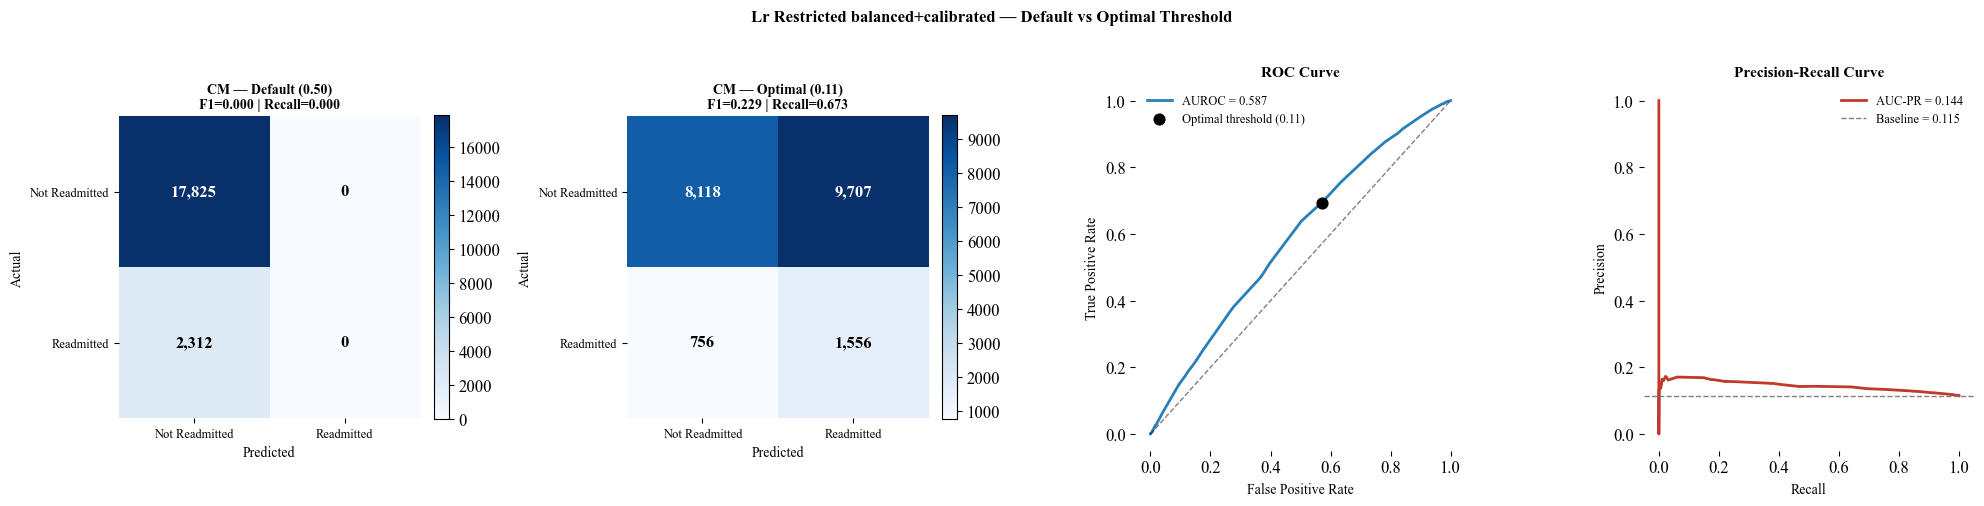

✓ Saved: improved_Lr_Restricted_balanced+calibrated.png

── LR_ADJUSTED ──
  C=0.001  → CV AUROC: 0.6349 ± 0.0042
  C=0.01   → CV AUROC: 0.6367 ± 0.0045
  C=0.1    → CV AUROC: 0.6364 ± 0.0051
  C=0.5    → CV AUROC: 0.6359 ± 0.0052
  C=1.0    → CV AUROC: 0.6357 ± 0.0054
  C=5.0    → CV AUROC: 0.6356 ± 0.0056
  C=10.0   → CV AUROC: 0.6354 ± 0.0055

  Best C = 0.01 | Best CV AUROC = 0.6367

  Optimal threshold (train F1-tuned): 0.128

  ── Threshold: Default (0.50) ──
  AUROC: 0.6404 | F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000 | AUC-PR: 0.1873

                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     17825
    Readmitted       0.00      0.00      0.00      2312

      accuracy                           0.89     20137
     macro avg       0.44      0.50      0.47     20137
  weighted avg       0.78      0.89      0.83     20137


  ── Threshold: Optimal (0.13) ──
  AUROC: 0.6404 | F1: 0.2589 | Precision: 0.1783 | Recall: 0.4728 | AUC-

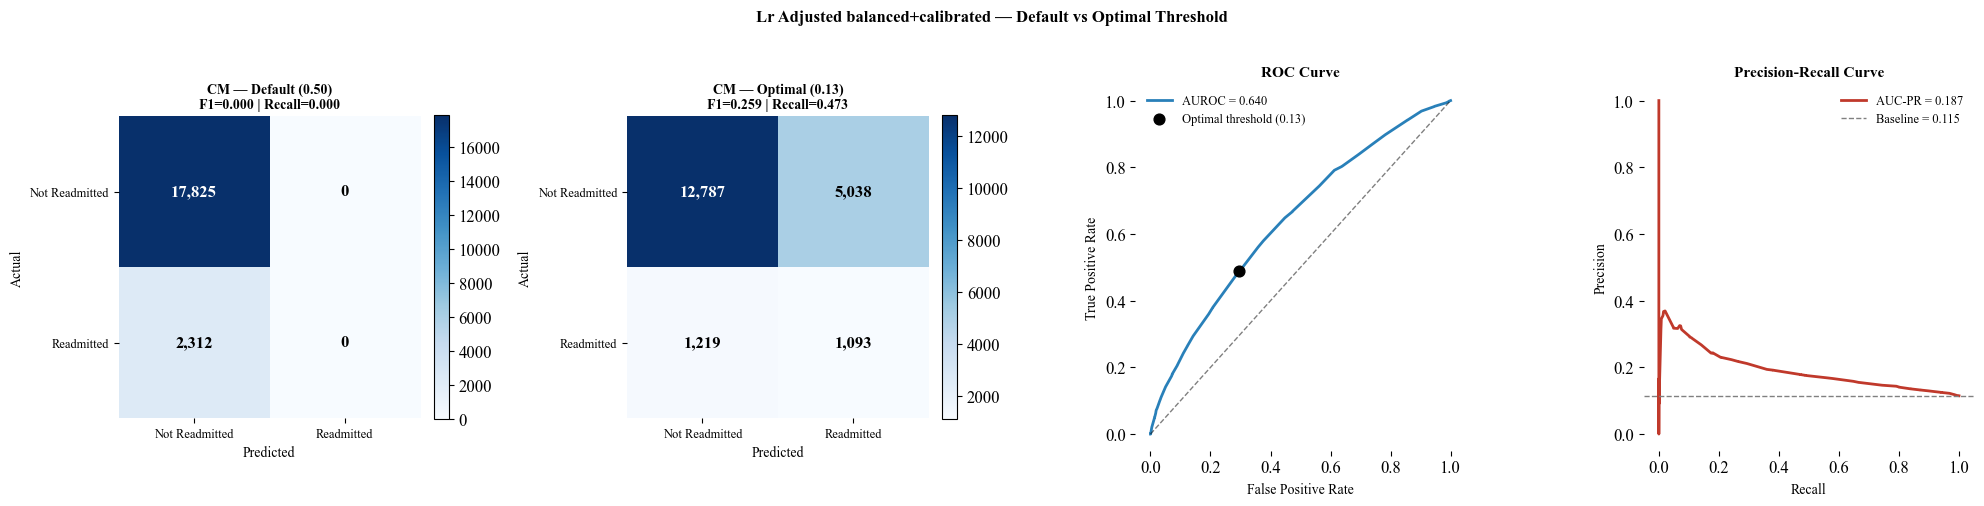

✓ Saved: improved_Lr_Adjusted_balanced+calibrated.png

  STEP 2: RANDOM FOREST — WIDER SEARCH + CALIBRATION
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best RF params: {'max_depth': 15, 'max_features': 0.5, 'min_samples_leaf': 9, 'min_samples_split': 4, 'n_estimators': 506}
Best CV AUROC:  0.6688

  Optimal threshold (train F1-tuned): 0.251

  ── Threshold: Default (0.50) ──
  AUROC: 0.6791 | F1: 0.1667 | Precision: 0.3544 | Recall: 0.1090 | AUC-PR: 0.2237

                precision    recall  f1-score   support

Not Readmitted       0.89      0.97      0.93     17825
    Readmitted       0.35      0.11      0.17      2312

      accuracy                           0.87     20137
     macro avg       0.62      0.54      0.55     20137
  weighted avg       0.83      0.87      0.84     20137


  ── Threshold: Optimal (0.25) ──
  AUROC: 0.6791 | F1: 0.2673 | Precision: 0.2458 | Recall: 0.2928 | AUC-PR: 0.2237

                precision    recall  f1-score   support

Not 

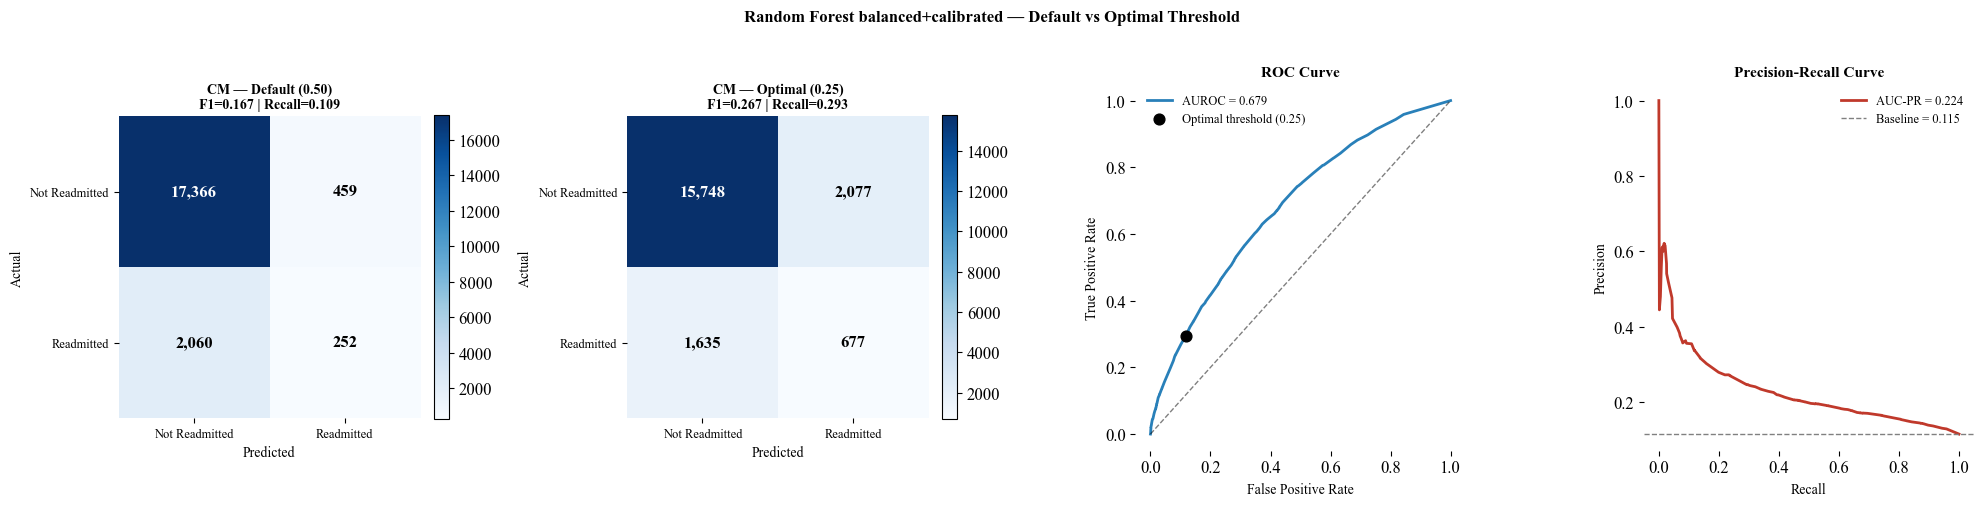

✓ Saved: improved_Random_Forest_balanced+calibrated.png

  STEP 3: XGBOOST — RANDOMIZED SEARCH + SHAP FEATURE SELECTION
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best XGB params: {'colsample_bytree': 0.6872700594236812, 'gamma': 0.4753571532049581, 'learning_rate': 0.15639878836228102, 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 321, 'reg_alpha': 0.15599452033620265, 'reg_lambda': 0.6161672243363989, 'subsample': 0.9464704583099741}
Best CV AUROC:   nan

Computing SHAP for feature selection...

Top 50 SHAP features selected:
                                     Feature  MeanSHAP
                    discharge_disposition_id  0.317510
                            number_inpatient  0.298613
                          num_lab_procedures  0.138695
                             num_medications  0.124505
                            number_diagnoses  0.090114
                            time_in_hospital  0.082988
                              num_procedures  0.0581

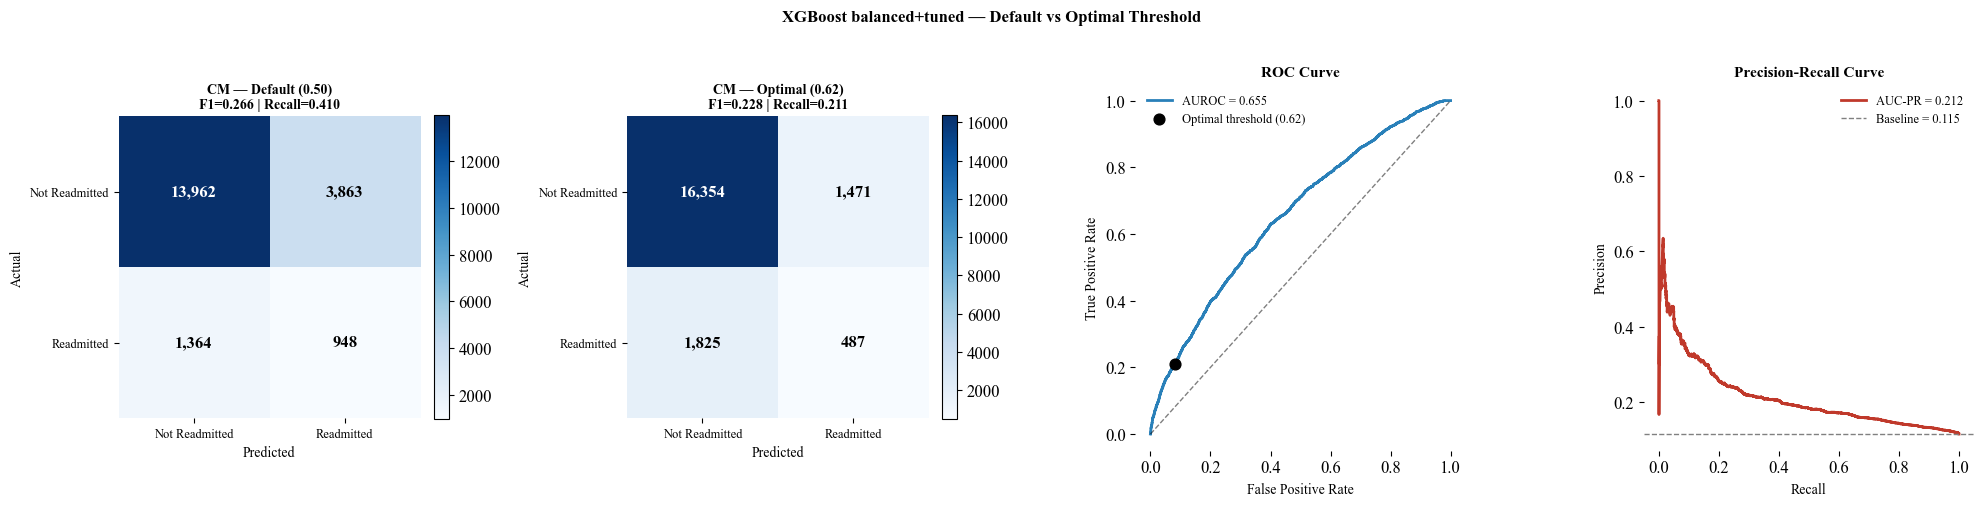

✓ Saved: improved_XGBoost_balanced+tuned.png

── XGBoost (top-50 SHAP features, calibrated) ──

Default (0.50)
AUROC: 0.6418 | F1: 0.1786 | Precision: 0.2907 | Recall: 0.1289 | AUC-PR: 0.1976

Optimal (0.63)
AUROC: 0.6418 | F1: 0.1559 | Precision: 0.3129 | Recall: 0.1038 | AUC-PR: 0.1976

Computing SHAP summary on selected features...


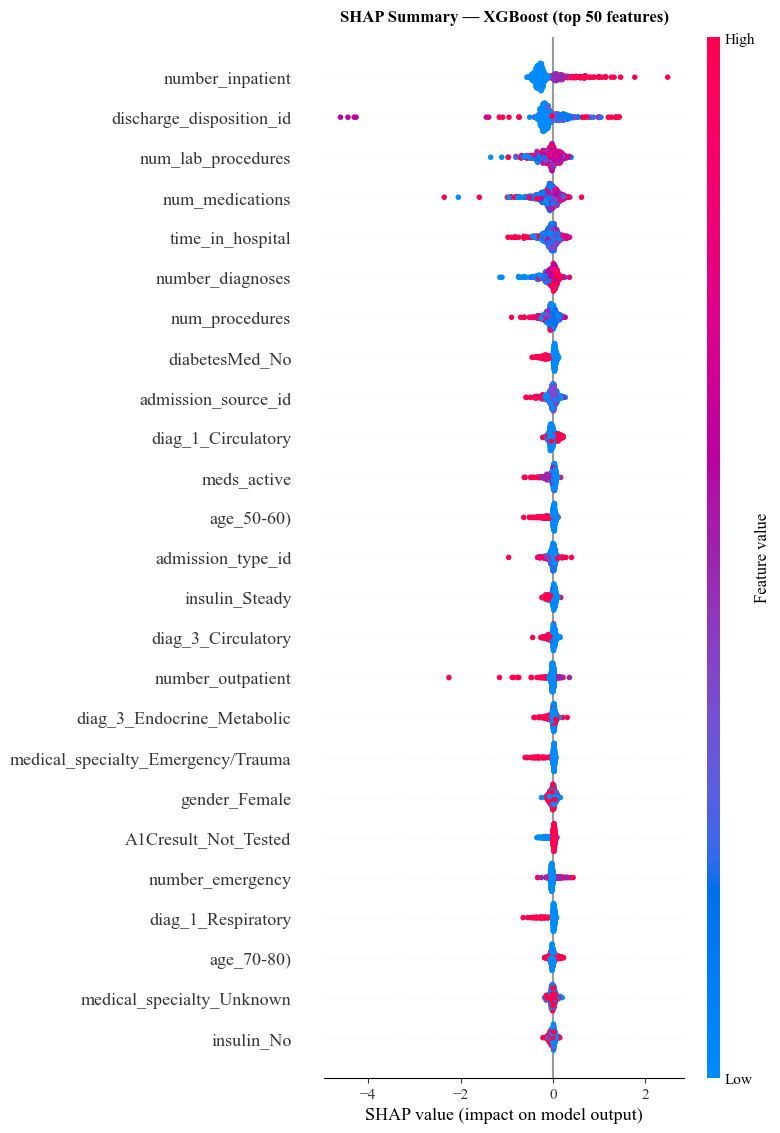


  STEP 4: NEURAL NETWORK — HYPERPARAMETER TUNING
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best NN params: {'activation': 'tanh', 'alpha': 0.00809397348116461, 'batch_size': 32, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.0005883605700319194}
Best CV AUROC:  0.6617

── Neural Network (tuned + calibrated) ──

  Optimal threshold (train F1-tuned): 0.148

  ── Threshold: Default (0.50) ──
  AUROC: 0.6712 | F1: 0.0187 | Precision: 0.6111 | Recall: 0.0095 | AUC-PR: 0.2139

                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     17825
    Readmitted       0.61      0.01      0.02      2312

      accuracy                           0.89     20137
     macro avg       0.75      0.50      0.48     20137
  weighted avg       0.85      0.89      0.83     20137


  ── Threshold: Optimal (0.15) ──
  AUROC: 0.6712 | F1: 0.2760 | Precision: 0.2124 | Recall: 0.3940 | AUC-PR: 0.2139

                precision    recall  f

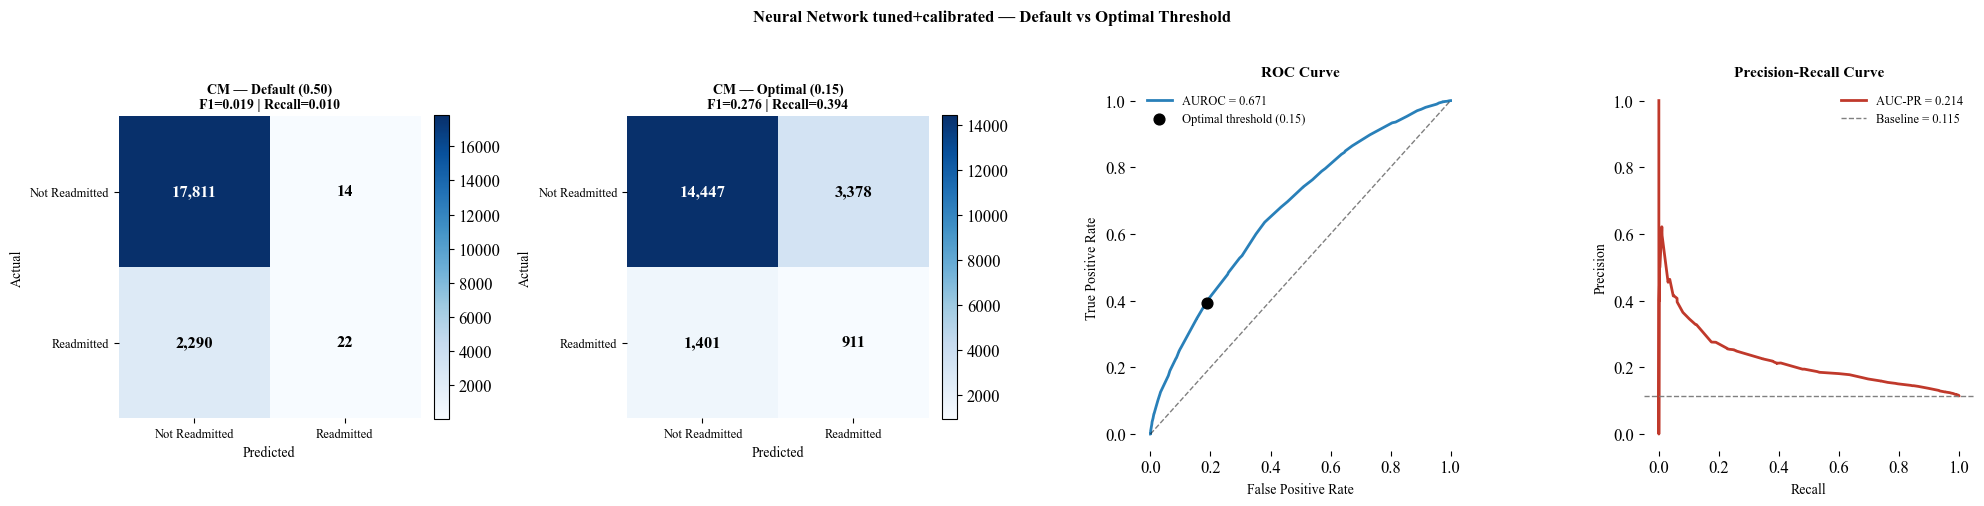

✓ Saved: improved_Neural_Network_tuned+calibrated.png

  STEP 5: THRESHOLD SENSITIVITY — XGBoost Best Model


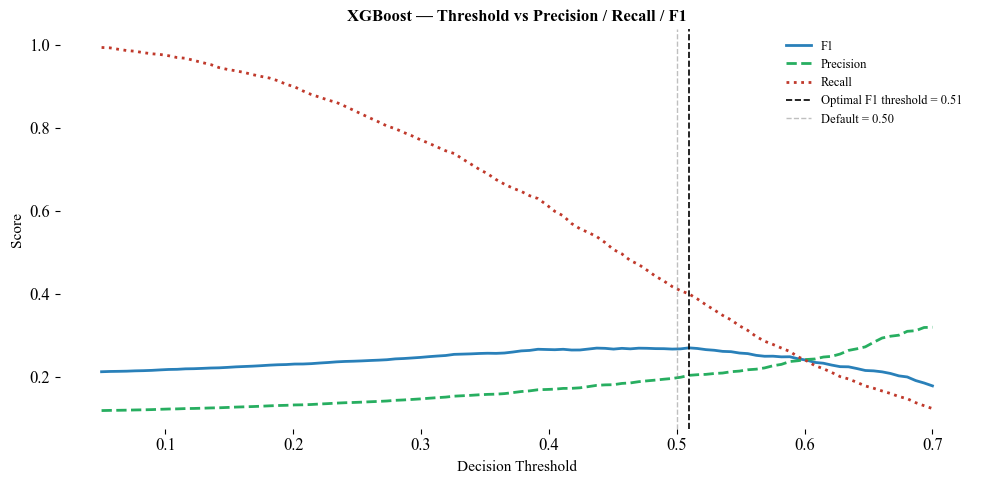

✓ Optimal F1 threshold: 0.510

 Saved: results_before_after.csv / .xlsx / .docx

  IMPROVEMENT PIPELINE COMPLETE
                                             Model   AUROC      F1  Recall  Version
Random Forest balanced+calibrated [Default (0.50)]  0.6791  0.1667   0.109 Improved
Random Forest balanced+calibrated [Optimal (0.25)]  0.6791  0.2673  0.2928 Improved
  Neural Network tuned+calibrated [Default (0.50)]  0.6712  0.0187  0.0095 Improved
  Neural Network tuned+calibrated [Optimal (0.15)]  0.6712   0.276   0.394 Improved
           XGBoost balanced+tuned [Default (0.50)]  0.6548  0.2662    0.41 Improved
           XGBoost balanced+tuned [Optimal (0.62)]  0.6548  0.2281  0.2106 Improved
  Lr Adjusted balanced+calibrated [Default (0.50)]  0.6404     0.0     0.0 Improved
  Lr Adjusted balanced+calibrated [Optimal (0.13)]  0.6404  0.2589  0.4728 Improved
Lr Restricted balanced+calibrated [Default (0.50)]  0.5869     0.0     0.0 Improved
Lr Restricted balanced+calibrated [Optimal (0.1

In [14]:


# MODEL IMPROVEMENT PIPELINE - MORE HYPERPARAMETER TUNING + SELECTION OF OPTIMAL THRESHOLDS

results_improved = {}  # store improved results

# function to find optimal threshold
def find_optimal_threshold(y_true, y_prob, metric='f1'):
    """Find threshold that maximises F1 (or recall) for class 1."""
    thresholds = np.linspace(0.01, 0.99, 200)
    best_score, best_thresh = 0, 0.5
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        if metric == 'f1':
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == 'recall':
            score = recall_score(y_true, y_pred, zero_division=0)
        if score > best_score:
            best_score = score
            best_thresh = t
    return best_thresh, best_score

# function to evaluate with optimal threshold 

def evaluate_improved(model_name, model, X_tr, X_te, y_tr, y_te,
                      is_nn=False, label=''):
    """Evaluate with both default (0.5) and optimal threshold."""
    tag = f"{model_name} {label}".strip()

    if is_nn:
        y_prob_tr = model.predict(X_tr).ravel()
        y_prob    = model.predict(X_te).ravel()
    else:
        y_prob_tr = model.predict_proba(X_tr)[:, 1]
        y_prob    = model.predict_proba(X_te)[:, 1]

    # Find threshold on TRAIN set, apply to TEST (no leakage)
    opt_thresh, _ = find_optimal_threshold(y_tr, y_prob_tr, metric='f1')
    print(f"\n  Optimal threshold (train F1-tuned): {opt_thresh:.3f}")

    y_pred_default = (y_prob >= 0.50).astype(int)
    y_pred_optimal = (y_prob >= opt_thresh).astype(int)

    for thresh_label, y_pred in [('Default (0.50)', y_pred_default),
                                   (f'Optimal ({opt_thresh:.2f})', y_pred_optimal)]:
        auroc  = roc_auc_score(y_te, y_prob)
        f1     = f1_score(y_te, y_pred)
        prec   = precision_score(y_te, y_pred, zero_division=0)
        rec    = recall_score(y_te, y_pred)
        auc_pr = average_precision_score(y_te, y_prob)
        cm     = confusion_matrix(y_te, y_pred)
        cr     = classification_report(y_te, y_pred,
                                        target_names=['Not Readmitted', 'Readmitted'])

        print(f"\n  ── Threshold: {thresh_label} ──")
        print(f"  AUROC: {auroc:.4f} | F1: {f1:.4f} | "
              f"Precision: {prec:.4f} | Recall: {rec:.4f} | AUC-PR: {auc_pr:.4f}")
        print(f"\n{cr}")

        store_key = f"{tag} [{thresh_label}]"
        results_improved[store_key] = {
            'AUROC': round(auroc, 4), 'F1': round(f1, 4),
            'Precision': round(prec, 4), 'Recall': round(rec, 4),
            'AUC-PR': round(auc_pr, 4), 'Threshold': round(opt_thresh, 3)
        }

    # ── Plot: Confusion matrices (both thresholds) + ROC + PR ──
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    for ax_idx, (thresh_label, y_pred, thresh_val) in enumerate([
        ('Default (0.50)', y_pred_default, 0.50),
        (f'Optimal ({opt_thresh:.2f})', y_pred_optimal, opt_thresh)
    ]):
        ax  = axes[ax_idx]
        cm_ = confusion_matrix(y_te, y_pred)
        im  = ax.imshow(cm_, cmap='Blues')
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(['Not Readmitted', 'Readmitted'], fontsize=9)
        ax.set_yticklabels(['Not Readmitted', 'Readmitted'], fontsize=9)
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f'{cm_[i,j]:,}', ha='center', va='center',
                        fontsize=12, fontweight='bold',
                        color='white' if cm_[i,j] > cm_.max()/2 else 'black')
        ax.set_xlabel('Predicted', fontsize=10)
        ax.set_ylabel('Actual', fontsize=10)
        f1_ = f1_score(y_te, y_pred, zero_division=0)
        rec_ = recall_score(y_te, y_pred, zero_division=0)
        ax.set_title(f'CM — {thresh_label}\nF1={f1_:.3f} | Recall={rec_:.3f}',
                     fontsize=10, fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        for spine in ax.spines.values(): spine.set_visible(False)

    # ROC
    ax = axes[2]
    fpr, tpr, thresh_roc = roc_curve(y_te, y_prob)
    auroc = roc_auc_score(y_te, y_prob)
    
    ax.plot(fpr, tpr, color='#2980B9', lw=2, label=f'AUROC = {auroc:.3f}')
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    
    # Correct mapping of optimal threshold
    idx = np.argmin(np.abs(thresh_roc - opt_thresh))
    opt_fpr = fpr[idx]
    opt_tpr = tpr[idx]
    
    ax.scatter(opt_fpr, opt_tpr,
               color='black', s=60, zorder=5,
               label=f'Optimal threshold ({opt_thresh:.2f})')
    
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title('ROC Curve', fontsize=11, fontweight='bold')
    ax.legend(frameon=False, fontsize=9)
    
    for spine in ax.spines.values():
        spine.set_visible(False)

    # PR Curve
    ax = axes[3]
    prec_c, rec_c, _ = precision_recall_curve(y_te, y_prob)
    auc_pr = average_precision_score(y_te, y_prob)
    baseline = y_te.mean()
    ax.plot(rec_c, prec_c, color='#C0392B', lw=2, label=f'AUC-PR = {auc_pr:.3f}')
    ax.axhline(y=baseline, linestyle='--', color='gray', lw=1,
               label=f'Baseline = {baseline:.3f}')
    ax.set_xlabel('Recall', fontsize=10)
    ax.set_ylabel('Precision', fontsize=10)
    ax.set_title('Precision-Recall Curve', fontsize=11, fontweight='bold')
    ax.legend(frameon=False, fontsize=9)
    for spine in ax.spines.values(): spine.set_visible(False)

    safe = tag.replace(' ', '_').replace('(','').replace(')','').replace('/','')
    plt.suptitle(f'{tag} — Default vs Optimal Threshold',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'Output/improved_{safe}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: improved_{safe}.png")

    return y_prob, opt_thresh



# STEP 1 — LR IMPROVED (balanced only, no SMOTE)

print("\n" + "="*60)
print("  STEP 1: LOGISTIC REGRESSION — BALANCED ONLY (NO SMOTE)")
print("="*60)

for lr_type in ['lr_restricted', 'lr_adjusted']:
    print(f"\n── {lr_type.upper()} ──")

    X_tr = X_lr_r_train.copy() if lr_type == 'lr_restricted' else X_lr_a_train_raw.copy()
    X_te = X_lr_r_test.copy()  if lr_type == 'lr_restricted' else X_lr_a_test_raw.copy()

    num_lr  = X_tr.select_dtypes(include=['int64','float64']).columns.tolist()
    X_tr, X_te = winsorize_df(X_tr, X_te, num_lr, CONFIG['winsorize_limits'])
    X_tr, X_te, _ = scale_df(X_tr, X_te, num_lr)

    # Try multiple C values to find best regularisation
    best_auroc, best_C, best_model = 0, 1.0, None
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=CONFIG['random_state'])
    for C in [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]:
        lr_m = LogisticRegression(class_weight='balanced', C=C,
                                   max_iter=CONFIG['lr_max_iter'],
                                   random_state=CONFIG['random_state'],
                                   solver='lbfgs', n_jobs=-1)
        scores = cross_val_score(lr_m, X_tr, y_trainval, cv=skf,
                                  scoring='roc_auc', n_jobs=-1)
        print(f"  C={C:<6} → CV AUROC: {scores.mean():.4f} ± {scores.std():.4f}")
        if scores.mean() > best_auroc:
            best_auroc = scores.mean()
            best_C     = C
            best_model = lr_m

    print(f"\n  Best C = {best_C} | Best CV AUROC = {best_auroc:.4f}")
    best_model.set_params(C=best_C)
    best_model.fit(X_tr, y_trainval)

    # Calibrate probabilities
    cal_model = CalibratedClassifierCV(best_model, method='isotonic', cv='prefit')
    cal_model.fit(X_tr, y_trainval)

    evaluate_improved(lr_type.replace('_',' ').title(), cal_model,
                      X_tr, X_te, y_trainval, y_test,
                      label='balanced+calibrated')

# STEP 2 — RANDOM FOREST IMPROVED (wider search + calibration)


print("\n" + "="*60)
print("  STEP 2: RANDOM FOREST — WIDER SEARCH + CALIBRATION")
print("="*60)

rf_param_dist = {
    'n_estimators':      randint(200, 600),
    'max_depth':         [5, 8, 10, 15, 20, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      ['sqrt', 'log2', 0.3, 0.5],
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=CONFIG['random_state'])

rf_base = RandomForestClassifier(class_weight='balanced',
                                  random_state=CONFIG['random_state'], n_jobs=-1)
rs_rf = RandomizedSearchCV(rf_base, rf_param_dist, n_iter=30,
                            cv=skf, scoring='roc_auc',
                            random_state=CONFIG['random_state'],
                            n_jobs=-1, verbose=1)
rs_rf.fit(X_trainval, y_trainval)

print(f"\nBest RF params: {rs_rf.best_params_}")
print(f"Best CV AUROC:  {rs_rf.best_score_:.4f}")

# Calibrate
rf_cal = CalibratedClassifierCV(rs_rf.best_estimator_,
                                  method='isotonic', cv='prefit')
rf_cal.fit(X_trainval, y_trainval)

evaluate_improved('Random Forest', rf_cal,
                   X_trainval, X_test, y_trainval, y_test,
                   label='balanced+calibrated')


# STEP 3 — XGBOOST IMPROVED (Bayesian-style random search)


class XGBClassifierWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, **kwargs):
        self.model = XGBClassifier(**kwargs)

    def fit(self, X, y):
        self.model.fit(X, y)
        self.classes_ = np.unique(y)  # CRITICAL
        return self

    def predict(self, X):
        return self.model.predict(X)

    def predict_proba(self, X):
        return self.model.predict_proba(X)

print("\n" + "="*60)
print("  STEP 3: XGBOOST — RANDOMIZED SEARCH + SHAP FEATURE SELECTION")
print("="*60)

scale_pos = (y_trainval == 0).sum() / (y_trainval == 1).sum()

xgb_param_dist = {
    'n_estimators':       randint(200, 800),
    'max_depth':          randint(3, 9),
    'learning_rate':      uniform(0.01, 0.2),
    'subsample':          uniform(0.6, 0.4),
    'colsample_bytree':   uniform(0.5, 0.5),
    'min_child_weight':   randint(1, 10),
    'gamma':              uniform(0, 0.5),
    'reg_alpha':          uniform(0, 1.0),
    'reg_lambda':         uniform(0.5, 2.0),
}

xgb_base = XGBClassifier(objective='binary:logistic',
                           scale_pos_weight=scale_pos,
                           eval_metric='logloss',
                           random_state=CONFIG['random_state'],
                           use_label_encoder=False, n_jobs=-1)

rs_xgb = RandomizedSearchCV(xgb_base, xgb_param_dist, n_iter=40,
                              cv=skf, scoring='roc_auc',
                              random_state=CONFIG['random_state'],
                              n_jobs=-1, verbose=1)
rs_xgb.fit(X_trainval, y_trainval)

print(f"\nBest XGB params: {rs_xgb.best_params_}")
print(f"Best CV AUROC:   {rs_xgb.best_score_:.4f}")

xgb_best = rs_xgb.best_estimator_

# ── SHAP-guided feature selection ──
print("\nComputing SHAP for feature selection...")
explainer   = shap.TreeExplainer(xgb_best)
shap_sample = X_trainval.sample(1000, random_state=CONFIG['random_state'])
shap_vals   = explainer.shap_values(shap_sample)

# Mean absolute SHAP per feature
mean_shap = pd.DataFrame({
    'Feature':    X_trainval.columns,
    'MeanSHAP':   np.abs(shap_vals).mean(axis=0)
}).sort_values('MeanSHAP', ascending=False)

# Keep top-50 features by SHAP importance
TOP_N_FEATURES = 50
top_features = mean_shap.head(TOP_N_FEATURES)['Feature'].tolist()
print(f"\nTop {TOP_N_FEATURES} SHAP features selected:")
print(mean_shap.head(TOP_N_FEATURES).to_string(index=False))

X_tr_shap = X_trainval[top_features]
X_te_shap = X_test[top_features]

# Retrain XGBoost on SHAP-selected features
xgb_shap = XGBClassifierWrapper(**rs_xgb.best_params_,
                           objective='binary:logistic',
                           scale_pos_weight=scale_pos,
                           eval_metric='logloss',
                           random_state=CONFIG['random_state'],
                           use_label_encoder=False, n_jobs=-1)


cv_shap = cross_val_score(xgb_shap, X_tr_shap, y_trainval,
                           cv=skf, scoring='roc_auc', n_jobs=-1)
print(f"\nXGB (SHAP-selected, top {TOP_N_FEATURES}) CV AUROC: "
      f"{cv_shap.mean():.4f} ± {cv_shap.std():.4f}")

xgb_shap.fit(X_tr_shap, y_trainval)

# Get train probabilities
train_probs = xgb_shap.predict_proba(X_tr_shap)[:, 1]

# Fit isotonic calibrator on TRAIN
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(train_probs, y_trainval)

# Get calibrated test probabilities
test_probs = xgb_shap.predict_proba(X_te_shap)[:, 1]
test_probs_cal = iso.transform(test_probs)

# Evaluate full features version
print("\n── XGBoost (all features, balanced) ──")
evaluate_improved('XGBoost', xgb_best,
                   X_trainval, X_test, y_trainval, y_test,
                   label='balanced+tuned')

#  Evaluate using calibrated probabilities manually
opt_thresh, _ = find_optimal_threshold(y_trainval, train_probs)

y_pred_default = (test_probs_cal >= 0.50).astype(int)
y_pred_optimal = (test_probs_cal >= opt_thresh).astype(int)

print(f"\n── XGBoost (top-{TOP_N_FEATURES} SHAP features, calibrated) ──")

for name, y_pred in [
    ('Default (0.50)', y_pred_default),
    (f'Optimal ({opt_thresh:.2f})', y_pred_optimal)
]:
    auroc  = roc_auc_score(y_test, test_probs_cal)
    f1     = f1_score(y_test, y_pred)
    prec   = precision_score(y_test, y_pred, zero_division=0)
    rec    = recall_score(y_test, y_pred)
    auc_pr = average_precision_score(y_test, test_probs_cal)

    print(f"\n{name}")
    print(f"AUROC: {auroc:.4f} | F1: {f1:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | AUC-PR: {auc_pr:.4f}")

# New SHAP plot on selected features
print("\nComputing SHAP summary on selected features...")
shap_sample2 = X_te_shap.sample(min(500, len(X_te_shap)),
                                  random_state=CONFIG['random_state'])
shap_vals2   = shap.TreeExplainer(xgb_shap.model).shap_values(shap_sample2)

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_vals2, shap_sample2,
                   plot_type='dot', max_display=25, show=False)
plt.title(f'SHAP Summary — XGBoost (top {TOP_N_FEATURES} features)',
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'Output/shap_xgb_top{TOP_N_FEATURES}.png', dpi=300, bbox_inches='tight')
plt.show()

# STEP 4 — NEURAL NETWORK (MLP) HYPERPARAMETER TUNING


print("\n" + "="*60)
print("  STEP 4: NEURAL NETWORK — HYPERPARAMETER TUNING")
print("="*60)

from sklearn.neural_network import MLPClassifier

nn_param_dist = {
    'hidden_layer_sizes': [(32,), (64,), (128,), (64, 32), (128, 64)],
    'activation': ['relu', 'tanh'],
    'alpha': uniform(1e-5, 1e-2),
    'learning_rate_init': uniform(1e-4, 5e-3),
    'batch_size': [32, 64, 128],
}

nn_base = MLPClassifier(
    max_iter=300,
    random_state=CONFIG['random_state']
)

rs_nn = RandomizedSearchCV(
    nn_base,
    nn_param_dist,
    n_iter=25,
    cv=skf,
    scoring='roc_auc',
    random_state=CONFIG['random_state'],
    n_jobs=-1,
    verbose=1
)

rs_nn.fit(X_trainval, y_trainval)

print(f"\nBest NN params: {rs_nn.best_params_}")
print(f"Best CV AUROC:  {rs_nn.best_score_:.4f}")

nn_best = rs_nn.best_estimator_

# optional calibration (VERY important for thresholding consistency)
nn_cal = CalibratedClassifierCV(nn_best, method='isotonic', cv='prefit')
nn_cal.fit(X_trainval, y_trainval)

# Evaluate NN
print("\n── Neural Network (tuned + calibrated) ──")

evaluate_improved(
    'Neural Network',
    nn_cal,
    X_trainval,
    X_test,
    y_trainval,
    y_test,
    label='tuned+calibrated'
)

# results_improved['Neural Network (Best)'] = results_improved.pop(
#     [k for k in results_improved if 'Neural Network' in k][-1]
# )


# STEP 5 — THRESHOLD SENSITIVITY ANALYSIS


print("\n" + "="*60)
print("  STEP 5: THRESHOLD SENSITIVITY — XGBoost Best Model")
print("="*60)

y_prob_xgb = xgb_best.predict_proba(X_test)[:, 1]
thresholds  = np.linspace(0.05, 0.70, 100)
f1s, precs, recs = [], [], []

for t in thresholds:
    yp = (y_prob_xgb >= t).astype(int)
    f1s.append(f1_score(y_test, yp, zero_division=0))
    precs.append(precision_score(y_test, yp, zero_division=0))
    recs.append(recall_score(y_test, yp, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1s,   color='#2980B9', lw=2, label='F1')
ax.plot(thresholds, precs, color='#27AE60', lw=2, label='Precision', linestyle='--')
ax.plot(thresholds, recs,  color='#C0392B', lw=2, label='Recall',    linestyle=':')

best_t = thresholds[np.argmax(f1s)]
ax.axvline(x=best_t, color='black', linestyle='--', lw=1.2,
           label=f'Optimal F1 threshold = {best_t:.2f}')
ax.axvline(x=0.50,  color='gray',  linestyle='--', lw=1.0, alpha=0.5,
           label='Default = 0.50')

ax.set_xlabel('Decision Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('XGBoost — Threshold vs Precision / Recall / F1',
             fontsize=12, fontweight='bold')
ax.legend(frameon=False, fontsize=9)
for spine in ax.spines.values(): spine.set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.savefig('Output/threshold_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Optimal F1 threshold: {best_t:.3f}")

# STEP 6 — COMPARISON: BEFORE vs AFTER

# Merge old results_store + new results_improved for comparison
before_after = {}
for k, v in results_store.items():
    before_after[k] = {**v, 'Version': 'Original'}
for k, v in results_improved.items():
    before_after[k] = {**v, 'Version': 'Improved'}

summary_df = pd.DataFrame(before_after).T.reset_index()
summary_df.columns = ['Model', 'AUROC', 'F1', 'Precision', 'Recall', 'AUC-PR', 'Version', 'Threshold']
summary_df = summary_df.sort_values(['Version', 'AUROC'], ascending=[True, False])

# Export
summary_df.to_csv('Output/results_before_after.csv', index=False)
summary_df.to_excel('Output/results_before_after.xlsx', index=False, sheet_name='Results')

doc = Document()
doc.add_heading('Before vs After Model Improvement', 0)
table = doc.add_table(rows=1, cols=len(summary_df.columns))
table.style = 'Light Grid Accent 1'
table.alignment = WD_TABLE_ALIGNMENT.CENTER
for i, col in enumerate(summary_df.columns):
    table.rows[0].cells[i].text = col
for _, row in summary_df.iterrows():
    cells = table.add_row().cells
    for i, val in enumerate(row):
        cells[i].text = str(val)
doc.save('Output/results_before_after.docx')

print("\n Saved: results_before_after.csv / .xlsx / .docx")
print("\n" + "="*60)
print("  IMPROVEMENT PIPELINE COMPLETE")
print("="*60)
print(summary_df[['Model','AUROC','F1','Recall','Version']].to_string(index=False))
